# **IMPORT LIB, CONFIG AND DATA PREPARATION**

In [372]:
# ============================================================
# 0. IMPORT LIBRARIES & CONFIG
# ============================================================

import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from lifetimes import BetaGeoFitter, GammaGammaFitter

from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    roc_auc_score,
    average_precision_score
)

from scipy.stats import spearmanr

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIG
# ============================================================

LOCAL_DATA_DIR = Path(r"E:\marketing for DS\marketing-driven-data-unlock\data\raw")
RELATIVE_DATA_DIR = Path("../data/raw")

REQUIRED_FILES = [
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_sellers_dataset.csv"
]

def find_data_dir(candidate_dirs, required_files):
    for p in candidate_dirs:
        if p.exists() and all((p / f).exists() for f in required_files):
            return p
    raise FileNotFoundError(
        "Không tìm thấy thư mục chứa đủ 3 file Olist: "
        + ", ".join(required_files)
    )

DATA_DIR = find_data_dir(
    candidate_dirs=[LOCAL_DATA_DIR, RELATIVE_DATA_DIR, Path(".")],
    required_files=REQUIRED_FILES
)

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ORDERS_PATH = DATA_DIR / "olist_orders_dataset.csv"
ITEMS_PATH = DATA_DIR / "olist_order_items_dataset.csv"
SELLERS_PATH = DATA_DIR / "olist_sellers_dataset.csv"

COMMISSION_RATE = 0.15
HORIZONS = [30, 60, 90]

ANALYSIS_START = pd.Timestamp("2017-01-01")

# Sửa lỗi logic: lấy hết ngày 2018-04-30, không chỉ lấy 00:00:00
CALIBRATION_END = pd.Timestamp("2018-04-30 23:59:59")

MAX_HOLDOUT_END = CALIBRATION_END + pd.Timedelta(days=max(HORIZONS))

print("Data dir:", DATA_DIR)
print("Output dir:", OUTPUT_DIR)
print("Calibration end:", CALIBRATION_END)
print("Max holdout end:", MAX_HOLDOUT_END)
print("Commission rate:", COMMISSION_RATE)

Data dir: ../data/raw
Output dir: outputs
Calibration end: 2018-04-30 23:59:59
Max holdout end: 2018-07-29 23:59:59
Commission rate: 0.15


In [373]:
# ============================================================
# 2. LOAD RAW DATA
# ============================================================

orders = pd.read_csv(
    ORDERS_PATH,
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

items = pd.read_csv(
    ITEMS_PATH,
    parse_dates=["shipping_limit_date"]
)

sellers = pd.read_csv(SELLERS_PATH)

print("orders:", orders.shape)
print("items:", items.shape)
print("sellers:", sellers.shape)

orders: (99441, 8)
items: (112650, 7)
sellers: (3095, 4)


In [374]:
# ============================================================
# 3. CLEAN & JOIN DATA
# ============================================================

tx = (
    items
    .merge(orders, on="order_id", how="left")
    .merge(sellers, on="seller_id", how="left")
)

tx = tx[
    (tx["order_status"] == "delivered") &
    (tx["order_purchase_timestamp"].notna()) &
    (tx["seller_id"].notna()) &
    (tx["order_id"].notna()) &
    (tx["price"].notna()) &
    (tx["price"] > 0)
].copy()

tx["transaction_date"] = tx["order_purchase_timestamp"]
tx["gmv"] = tx["price"].astype(float)

tx = tx[
    (tx["transaction_date"] >= ANALYSIS_START) &
    (tx["transaction_date"] <= MAX_HOLDOUT_END)
].copy()

print("Clean item-level transactions:", tx.shape)
print("Date range:", tx["transaction_date"].min(), "→", tx["transaction_date"].max())
print("Unique sellers:", tx["seller_id"].nunique())

Clean item-level transactions: (102063, 19)
Date range: 2017-01-05 11:56:06 → 2018-07-29 23:52:17
Unique sellers: 2772


In [375]:
# ============================================================
# 4. BUILD SELLER-ORDER TRANSACTION TABLE
# ============================================================

seller_order_tx = (
    tx
    .groupby(["seller_id", "order_id"], as_index=False)
    .agg(
        transaction_date=("transaction_date", "min"),
        gmv=("gmv", "sum"),
        freight_value=("freight_value", "sum"),
        n_items=("order_item_id", "count"),
        seller_state=("seller_state", "first"),
        seller_city=("seller_city", "first")
    )
    .sort_values(["seller_id", "transaction_date"])
)

print("Seller-order transaction table:", seller_order_tx.shape)
print("Date range:", seller_order_tx["transaction_date"].min(), "→", seller_order_tx["transaction_date"].max())
print("Unique sellers:", seller_order_tx["seller_id"].nunique())

Seller-order transaction table: (90481, 8)
Date range: 2017-01-05 11:56:06 → 2018-07-29 23:52:17
Unique sellers: 2772


In [376]:
# ============================================================
# 6. SPLIT CALIBRATION / HOLDOUT
# ============================================================

cal_tx = seller_order_tx[
    seller_order_tx["transaction_date"] <= CALIBRATION_END
].copy()

holdout_tx = seller_order_tx[
    (seller_order_tx["transaction_date"] > CALIBRATION_END) &
    (seller_order_tx["transaction_date"] <= MAX_HOLDOUT_END)
].copy()

print("Calibration transactions:", cal_tx.shape)
print("Holdout transactions:", holdout_tx.shape)

print("Calibration date range:", cal_tx["transaction_date"].min(), "→", cal_tx["transaction_date"].max())
print("Holdout date range:", holdout_tx["transaction_date"].min(), "→", holdout_tx["transaction_date"].max())

Calibration transactions: (71743, 8)
Holdout transactions: (18738, 8)
Calibration date range: 2017-01-05 11:56:06 → 2018-04-30 23:47:26
Holdout date range: 2018-05-01 00:02:11 → 2018-07-29 23:52:17


In [377]:
# ============================================================
# 7. BUILD CUSTOM BG/NBD SUMMARY
# ============================================================

def build_btyd_summary(
    transactions,
    calibration_end,
    seller_col="seller_id",
    order_col="order_id",
    date_col="transaction_date",
    monetary_col="gmv"
):
    """
    Build seller-level R-F-T summary for BG/NBD and Gamma-Gamma.
    Uses transaction-level seller-order data.
    """
    df = transactions[transactions[date_col] <= calibration_end].copy()
    df = df.sort_values([seller_col, date_col, order_col])
    
    # Rank transactions per seller
    df["txn_rank"] = df.groupby(seller_col).cumcount() + 1
    
    base = (
        df
        .groupby(seller_col)
        .agg(
            total_orders_cal=(order_col, "nunique"),
            total_gmv_cal=(monetary_col, "sum"),
            historical_aov_cal=(monetary_col, "mean"),
            first_order_date=(date_col, "min"),
            last_order_date=(date_col, "max")
        )
    )
    
    # BG/NBD frequency = repeat transactions
    base["frequency"] = (base["total_orders_cal"] - 1).clip(lower=0)
    
    # Time variables in days
    base["recency"] = (
        base["last_order_date"] - base["first_order_date"]
    ).dt.total_seconds() / 86400
    
    base["T"] = (
        pd.Timestamp(calibration_end) - base["first_order_date"]
    ).dt.total_seconds() / 86400
    
    # T must be positive
    base["T"] = base["T"].clip(lower=1e-3)
    
    # monetary_value for Gamma-Gamma = average value of repeat transactions
    repeat_tx = df[df["txn_rank"] > 1].copy()
    
    repeat_monetary = (
        repeat_tx
        .groupby(seller_col)[monetary_col]
        .mean()
        .rename("monetary_value")
    )
    
    base = base.join(repeat_monetary, how="left")
    base["monetary_value"] = base["monetary_value"].fillna(0)
    
    # Keep useful columns
    summary = base[
        [
            "frequency",
            "recency",
            "T",
            "monetary_value",
            "total_orders_cal",
            "total_gmv_cal",
            "historical_aov_cal",
            "first_order_date",
            "last_order_date"
        ]
    ].copy()
    
    return summary


summary = build_btyd_summary(
    transactions=cal_tx,
    calibration_end=CALIBRATION_END
)

print("BG/NBD summary:", summary.shape)
display(summary.head())

BG/NBD summary: (2248, 9)


,frequency,recency,T,monetary_value,total_orders_cal,total_gmv_cal,historical_aov_cal,first_order_date,last_order_date
seller_id,,,,,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,2,21.416308,216.071458,895.000000,3,2685.00,895.000000,2017-09-26 22:17:05,2017-10-18 08:16:34
001cca7ae9ae17fb1caed9dfb1094831,191,447.554861,450.204109,125.739424,192,24116.13,125.604844,2017-02-04 19:06:04,2018-04-28 08:25:04
002100f778ceb8431b7a1020ff7ab48f,49,210.498519,228.957963,24.626531,50,1216.60,24.332000,2017-09-14 01:00:31,2018-04-12 12:58:23
003554e2dce176b5555353e4f3555ac8,0,0.000000,136.713588,0.000000,1,120.00,120.000000,2017-12-15 06:52:25,2017-12-15 06:52:25
004c9cd9d87a3c30c522c48c4fc07416,153,444.125498,458.559317,124.838170,154,19220.23,124.806688,2017-01-27 10:34:34,2018-04-16 13:35:17


In [378]:
# ============================================================
# 8. ADD ACTUAL HOLDOUT TARGETS FOR EACH HORIZON
# ============================================================

def add_actuals_by_horizon(
    score_df,
    transactions,
    calibration_end,
    horizons,
    seller_col="seller_id",
    order_col="order_id",
    date_col="transaction_date",
    monetary_col="gmv"
):
    out = score_df.copy()
    cal = pd.Timestamp(calibration_end)
    
    for h in horizons:
        end_date = cal + pd.Timedelta(days=int(h))
        
        h_tx = transactions[
            (transactions[date_col] > cal) &
            (transactions[date_col] <= end_date)
        ].copy()
        
        actual = (
            h_tx
            .groupby(seller_col)
            .agg(
                **{
                    f"actual_orders_{h}d": (order_col, "nunique"),
                    f"actual_gmv_{h}d": (monetary_col, "sum")
                }
            )
        )
        
        out = out.join(actual, how="left")
        
        out[f"actual_orders_{h}d"] = out[f"actual_orders_{h}d"].fillna(0)
        out[f"actual_gmv_{h}d"] = out[f"actual_gmv_{h}d"].fillna(0)
        out[f"actual_active_{h}d"] = (
            out[f"actual_orders_{h}d"] > 0
        ).astype(int)
    
    return out


score = add_actuals_by_horizon(
    score_df=summary,
    transactions=seller_order_tx,
    calibration_end=CALIBRATION_END,
    horizons=HORIZONS
)

for h in HORIZONS:
    print(
        f"Horizon {h}d | Existing-seller active rate:",
        round(score[f"actual_active_{h}d"].mean(), 4),
        "| Existing-seller actual orders:",
        int(score[f"actual_orders_{h}d"].sum()),
        "| Existing-seller actual GMV:",
        round(score[f"actual_gmv_{h}d"].sum(), 2)
    )

Horizon 30d | Existing-seller active rate: 0.4115 | Existing-seller actual orders: 6367 | Existing-seller actual GMV: 894056.48
Horizon 60d | Existing-seller active rate: 0.4929 | Existing-seller actual orders: 11751 | Existing-seller actual GMV: 1637110.34
Horizon 90d | Existing-seller active rate: 0.5271 | Existing-seller actual orders: 16406 | Existing-seller actual GMV: 2261429.39


# **TRAIN BG/NBD**

## **Fit BG/NBD**

In [379]:
# ============================================================
# 9. FIT BG/NBD MODEL
# ============================================================
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(
    frequency=score["frequency"],
    recency=score["recency"],
    T=score["T"]
)
print(bgf.summary)

           coef  se(coef)  lower 95% bound  upper 95% bound
r      0.445486  0.013303         0.419412         0.471561
alpha  3.365220  0.149995         3.071230         3.659210
a      0.144359  0.009843         0.125066         0.163652
b      2.291989  0.240068         1.821455         2.762523


In [380]:
# ============================================================
# 10. PREDICT FUTURE ORDERS WITH BG/NBD
# ============================================================

score["prob_alive"] = bgf.conditional_probability_alive(
    frequency=score["frequency"],
    recency=score["recency"],
    T=score["T"]
)

for h in HORIZONS:
    score[f"expected_orders_{h}d"] = bgf.conditional_expected_number_of_purchases_up_to_time(
        t=h,
        frequency=score["frequency"],
        recency=score["recency"],
        T=score["T"]
    )

    # Ranking score for future seller activity
    score[f"activity_score_{h}d"] = score[f"expected_orders_{h}d"]

    # Poisson-style approximation, not exact BG/NBD probability
    score[f"p_purchase_approx_{h}d"] = 1 - np.exp(-score[f"expected_orders_{h}d"])

display(
    score[
        [
            "frequency", "recency", "T",
            "prob_alive",
            "expected_orders_30d", "activity_score_30d", "p_purchase_approx_30d",
            "expected_orders_60d", "activity_score_60d", "p_purchase_approx_60d",
            "expected_orders_90d", "activity_score_90d", "p_purchase_approx_90d"
        ]
    ].head()
)


,frequency,recency,T,prob_alive,expected_orders_30d,activity_score_30d,p_purchase_approx_30d,expected_orders_60d,activity_score_60d,p_purchase_approx_60d,expected_orders_90d,activity_score_90d,p_purchase_approx_90d
seller_id,,,,,,,,,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,2,21.416308,216.071458,0.099162,0.032909,0.032909,0.032373,0.065367,0.065367,0.063276,0.097420,0.097420,0.092825
001cca7ae9ae17fb1caed9dfb1094831,191,447.554861,450.204109,0.997701,12.574934,12.574934,0.999997,25.038213,25.038213,1.000000,37.397244,37.397244,1.000000
002100f778ceb8431b7a1020ff7ab48f,49,210.498519,228.957963,0.853171,5.399887,5.399887,0.995483,10.712664,10.712664,0.999978,15.948371,15.948371,1.000000
003554e2dce176b5555353e4f3555ac8,0,0.000000,136.713588,1.000000,0.094579,0.094579,0.090245,0.187662,0.187662,0.171106,0.279443,0.279443,0.243795
004c9cd9d87a3c30c522c48c4fc07416,153,444.125498,458.559317,0.891200,8.840980,8.840980,0.999855,17.604879,17.604879,1.000000,26.296725,26.296725,1.000000


# **TRAIN GAMMA-GAMMA**

## **Fit Gamma-Gamma**

In [381]:
# ============================================================
# 12. PREPARE DATA FOR GAMMA-GAMMA
# ============================================================

gg_data = score[
    (score["frequency"] > 0) &
    (score["monetary_value"] > 0)
].copy()

print("Gamma-Gamma training sellers:", gg_data.shape[0])


Gamma-Gamma training sellers: 1833


In [382]:
# ============================================================
# 13. FIT GAMMA-GAMMA MODEL
# ============================================================

ggf = GammaGammaFitter(penalizer_coef=0.001)

ggf.fit(
    frequency=gg_data["frequency"],
    monetary_value=gg_data["monetary_value"]
)

print(ggf.summary)

       coef  se(coef)  lower 95% bound  upper 95% bound
p  8.612164  0.299870         8.024419         9.199908
q  1.097865  0.032549         1.034068         1.161662
v  8.715475  0.313936         8.100161         9.330789


In [383]:
# ============================================================
# 14. PREDICT EXPECTED AVERAGE GMV
# ============================================================

score["gg_expected_avg_gmv"] = np.nan

valid_gg = (
    (score["frequency"] > 0) &
    (score["monetary_value"] > 0)
)

score.loc[valid_gg, "gg_expected_avg_gmv"] = ggf.conditional_expected_average_profit(
    frequency=score.loc[valid_gg, "frequency"],
    monetary_value=score.loc[valid_gg, "monetary_value"]
)

# Fallback:
# Nếu seller không đủ điều kiện Gamma-Gamma, dùng historical AOV.
# Nếu vẫn thiếu, dùng median AOV của toàn bộ seller.
median_aov = score["historical_aov_cal"].median()

score["expected_avg_gmv"] = (
    score["gg_expected_avg_gmv"]
    .fillna(score["historical_aov_cal"])
    .fillna(median_aov)
)

score["expected_avg_gmv"] = score["expected_avg_gmv"].clip(lower=0)

display(
    score[
        [
            "frequency",
            "monetary_value",
            "historical_aov_cal",
            "gg_expected_avg_gmv",
            "expected_avg_gmv"
        ]
    ].head()
)

,frequency,monetary_value,historical_aov_cal,gg_expected_avg_gmv,expected_avg_gmv
seller_id,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,2,895.000000,895.000000,894.276630,894.276630
001cca7ae9ae17fb1caed9dfb1094831,191,125.739424,125.604844,125.777572,125.777572
002100f778ceb8431b7a1020ff7ab48f,49,24.626531,24.332000,24.798646,24.798646
003554e2dce176b5555353e4f3555ac8,0,0.000000,120.000000,NaN,120.000000
004c9cd9d87a3c30c522c48c4fc07416,153,124.838170,124.806688,124.885858,124.885858


In [384]:
# ============================================================
# 15. COMPUTE SELLER HORIZON VALUE FOR EACH HORIZON
# ============================================================

for h in HORIZONS:
    score[f"predicted_gmv_{h}d"] = (
        score[f"expected_orders_{h}d"] *
        score["expected_avg_gmv"]
    )

    # Expected marketplace commission over horizon, not full lifetime CLV
    score[f"expected_commission_{h}d"] = (
        score[f"predicted_gmv_{h}d"] *
        COMMISSION_RATE
    )

    score[f"actual_commission_{h}d"] = (
        score[f"actual_gmv_{h}d"] *
        COMMISSION_RATE
    )

display(
    score[
        [
            "expected_avg_gmv",
            "expected_orders_30d", "expected_commission_30d", "actual_commission_30d",
            "expected_orders_60d", "expected_commission_60d", "actual_commission_60d",
            "expected_orders_90d", "expected_commission_90d", "actual_commission_90d"
        ]
    ].head()
)


,expected_avg_gmv,expected_orders_30d,expected_commission_30d,actual_commission_30d,expected_orders_60d,expected_commission_60d,actual_commission_60d,expected_orders_90d,expected_commission_90d,actual_commission_90d
seller_id,,,,,,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,894.276630,0.032909,4.414461,0.000,0.065367,8.768389,0.000,0.097420,13.068032,0.000
001cca7ae9ae17fb1caed9dfb1094831,125.777572,12.574934,237.246702,0.000,25.038213,472.386845,36.150,37.397244,705.560188,55.635
002100f778ceb8431b7a1020ff7ab48f,24.798646,5.399887,20.086482,0.000,10.712664,39.848936,0.000,15.948371,59.324701,0.000
003554e2dce176b5555353e4f3555ac8,120.000000,0.094579,1.702429,0.000,0.187662,3.377924,0.000,0.279443,5.029969,0.000
004c9cd9d87a3c30c522c48c4fc07416,124.885858,8.840980,165.616998,52.425,17.604879,329.790066,52.425,26.296725,492.613363,52.425


# **VALIDATION METRICS & PLOTS**

In [385]:
# ============================================================
# 16. VALIDATION SETUP
# ============================================================

from scipy.stats import spearmanr, pearsonr, poisson
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    roc_auc_score,
    average_precision_score
)

# Horizon chính cho các plot chi tiết.
# Metrics vẫn được tính cho toàn bộ HORIZONS = [30, 60, 90].
# Đổi giá trị này sang 30 hoặc 90 nếu bạn muốn plot chi tiết theo horizon khác.
PRIMARY_PLOT_HORIZON = 60
H_EVAL = PRIMARY_PLOT_HORIZON

METRICS_OUTPUT_DIR = OUTPUT_DIR / "validation_metrics_ordered"
PLOTS_OUTPUT_DIR = OUTPUT_DIR / "validation_plots_ordered"
METRICS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PLOTS = False

def save_current_plot(filename):
    if SAVE_PLOTS:
        plt.savefig(PLOTS_OUTPUT_DIR / filename, dpi=150, bbox_inches="tight")

# Add seller attributes for segment diagnostics if needed.
if "seller_state" not in score.columns or "seller_city" not in score.columns:
    seller_attrs = (
        seller_order_tx
        .groupby("seller_id")
        .agg(
            seller_state=("seller_state", "first"),
            seller_city=("seller_city", "first")
        )
    )
    score = score.join(seller_attrs, how="left")

print("Primary plot horizon:", H_EVAL)
print("Metrics output dir:", METRICS_OUTPUT_DIR)
print("Plots output dir:", PLOTS_OUTPUT_DIR)


Primary plot horizon: 60
Metrics output dir: outputs/validation_metrics_ordered
Plots output dir: outputs/validation_plots_ordered


In [386]:
# ============================================================
# 17. HELPER FUNCTIONS
# ============================================================

def safe_divide(numerator, denominator):
    if denominator == 0 or pd.isna(denominator):
        return np.nan
    return numerator / denominator


def safe_pct_error(pred, actual):
    return safe_divide(pred - actual, actual)


def wape(actual, pred):
    actual = pd.Series(actual).fillna(0)
    pred = pd.Series(pred).fillna(0)
    denom = actual.abs().sum()
    if denom == 0:
        return np.nan
    return (actual - pred).abs().sum() / denom


def safe_spearman(actual, pred):
    actual = pd.Series(actual)
    pred = pd.Series(pred)
    ok = actual.notna() & pred.notna()

    if ok.sum() < 3:
        return np.nan
    if actual[ok].nunique() <= 1 or pred[ok].nunique() <= 1:
        return np.nan

    return spearmanr(actual[ok], pred[ok]).correlation


def safe_pearson(actual, pred):
    actual = pd.Series(actual)
    pred = pd.Series(pred)
    ok = actual.notna() & pred.notna()

    if ok.sum() < 3:
        return np.nan
    if actual[ok].nunique() <= 1 or pred[ok].nunique() <= 1:
        return np.nan

    return pearsonr(actual[ok], pred[ok])[0]


def lift_at_top_k(df, score_col, target_col, k=0.10):
    temp = df[[score_col, target_col]].dropna().copy()
    if len(temp) == 0:
        return np.nan

    temp = temp.sort_values(score_col, ascending=False)
    n_top = max(1, int(len(temp) * k))
    top = temp.head(n_top)

    base_rate = temp[target_col].mean()
    top_rate = top[target_col].mean()

    if base_rate == 0:
        return np.nan
    return top_rate / base_rate


def value_capture_at_k(df, pred_col, actual_col, k=0.10):
    temp = df[[pred_col, actual_col]].dropna().copy()
    if len(temp) == 0:
        return np.nan

    temp = temp.sort_values(pred_col, ascending=False)
    n_top = max(1, int(len(temp) * k))
    top = temp.head(n_top)

    total_actual = temp[actual_col].sum()
    if total_actual == 0:
        return np.nan

    return top[actual_col].sum() / total_actual


def value_lift_at_k(df, pred_col, actual_col, k=0.10):
    capture = value_capture_at_k(df, pred_col, actual_col, k=k)
    if pd.isna(capture):
        return np.nan
    return capture / k


def decile_calibration(df, pred_col, actual_col, n_bins=10):
    temp = df[[pred_col, actual_col]].dropna().copy()
    if len(temp) == 0:
        return pd.DataFrame()

    q = min(n_bins, len(temp))
    temp["decile"] = (
        pd.qcut(
            temp[pred_col].rank(method="first"),
            q=q,
            labels=False,
            duplicates="drop"
        ) + 1
    )

    out = (
        temp
        .groupby("decile")
        .agg(
            n_sellers=("decile", "size"),
            avg_pred=(pred_col, "mean"),
            avg_actual=(actual_col, "mean"),
            total_pred=(pred_col, "sum"),
            total_actual=(actual_col, "sum")
        )
        .reset_index()
        .sort_values("decile", ascending=False)
    )

    out["actual_over_pred"] = np.where(
        out["total_pred"] > 0,
        out["total_actual"] / out["total_pred"],
        np.nan
    )

    out["error_pct"] = np.where(
        out["total_actual"] > 0,
        (out["total_pred"] - out["total_actual"]) / out["total_actual"],
        np.nan
    )

    return out


def value_capture_curve(df, pred_col, actual_col):
    temp = df[[pred_col, actual_col]].dropna().copy()
    if len(temp) == 0:
        return pd.DataFrame()

    temp = temp.sort_values(pred_col, ascending=False).reset_index(drop=True)
    temp["cum_seller_pct"] = (np.arange(len(temp)) + 1) / len(temp)

    total_actual = temp[actual_col].sum()
    if total_actual > 0:
        temp["cum_actual_value_pct"] = temp[actual_col].cumsum() / total_actual
    else:
        temp["cum_actual_value_pct"] = np.nan

    return temp[["cum_seller_pct", "cum_actual_value_pct"]]


def value_lift_by_decile(df, pred_col, actual_col, n_bins=10):
    temp = df[[pred_col, actual_col]].dropna().copy()
    if len(temp) == 0:
        return pd.DataFrame()

    temp["decile"] = (
        pd.qcut(
            temp[pred_col].rank(method="first"),
            q=n_bins,
            labels=False,
            duplicates="drop"
        ) + 1
    )

    out = (
        temp
        .groupby("decile")
        .agg(
            n_sellers=("decile", "size"),
            total_actual_value=(actual_col, "sum"),
            avg_actual_value=(actual_col, "mean"),
            total_pred_value=(pred_col, "sum"),
            avg_pred_value=(pred_col, "mean")
        )
        .reset_index()
        .sort_values("decile", ascending=False)
    )

    baseline_avg_value = temp[actual_col].mean()
    out["baseline_avg_actual_value"] = baseline_avg_value
    out["value_lift"] = np.where(
        baseline_avg_value > 0,
        out["avg_actual_value"] / baseline_avg_value,
        np.nan
    )

    return out


def active_lift_by_decile(df, score_col, target_col, n_bins=10):
    temp = df[[score_col, target_col]].dropna().copy()
    if len(temp) == 0:
        return pd.DataFrame()

    temp["decile"] = (
        pd.qcut(
            temp[score_col].rank(method="first"),
            q=n_bins,
            labels=False,
            duplicates="drop"
        ) + 1
    )

    out = (
        temp
        .groupby("decile")
        .agg(
            n_sellers=("decile", "size"),
            active_rate=(target_col, "mean"),
            avg_score=(score_col, "mean")
        )
        .reset_index()
        .sort_values("decile", ascending=False)
    )

    base_rate = temp[target_col].mean()
    out["baseline_active_rate"] = base_rate
    out["lift"] = np.where(base_rate > 0, out["active_rate"] / base_rate, np.nan)

    return out


def make_frequency_bucket(series):
    return pd.cut(
        series,
        bins=[-1, 0, 1, 2, 5, 10, 50, np.inf],
        labels=["0", "1", "2", "3-5", "6-10", "11-50", "50+"]
    )


def segment_error_table(df, segment_col, pred_col, actual_col, min_n=20):
    rows = []

    for segment_value, temp in df.groupby(segment_col, dropna=False, observed=False):
        if len(temp) < min_n:
            continue

        pred = temp[pred_col]
        actual = temp[actual_col]

        rows.append({
            segment_col: segment_value,
            "n_sellers": len(temp),
            "total_pred": pred.sum(),
            "total_actual": actual.sum(),
            "error_pct": safe_pct_error(pred.sum(), actual.sum()),
            "wape": wape(actual, pred),
            "avg_pred": pred.mean(),
            "avg_actual": actual.mean()
        })

    return (
        pd.DataFrame(rows)
        .sort_values("total_actual", ascending=False)
        .reset_index(drop=True)
    )


def build_daily_tracking(
    score_df,
    bgf_model,
    transactions,
    calibration_end,
    horizon,
    commission_rate,
    seller_col="seller_id",
    order_col="order_id",
    date_col="transaction_date",
    monetary_col="gmv"
):
    cal = pd.Timestamp(calibration_end)
    days = np.arange(1, horizon + 1)
    eval_sellers = set(score_df.index)

    h_tx = transactions[
        (transactions[seller_col].isin(eval_sellers)) &
        (transactions[date_col] > cal) &
        (transactions[date_col] <= cal + pd.Timedelta(days=int(horizon)))
    ].copy()

    if len(h_tx) == 0:
        actual_daily = pd.DataFrame(
            index=days,
            data={"actual_orders": 0, "actual_gmv": 0.0}
        )
    else:
        h_tx["day_idx"] = np.ceil(
            (h_tx[date_col] - cal).dt.total_seconds() / 86400
        ).astype(int)
        h_tx["day_idx"] = h_tx["day_idx"].clip(lower=1, upper=horizon)

        actual_daily = (
            h_tx
            .groupby("day_idx")
            .agg(
                actual_orders=(order_col, "count"),
                actual_gmv=(monetary_col, "sum")
            )
            .reindex(days, fill_value=0)
        )

    actual_daily["actual_commission"] = actual_daily["actual_gmv"] * commission_rate

    pred_rows = []
    for d in days:
        pred_orders_seller = bgf_model.conditional_expected_number_of_purchases_up_to_time(
            t=int(d),
            frequency=score_df["frequency"],
            recency=score_df["recency"],
            T=score_df["T"]
        )
        pred_orders_seller = pd.Series(pred_orders_seller, index=score_df.index)

        pred_orders_total = pred_orders_seller.sum()
        pred_gmv_total = (pred_orders_seller * score_df["expected_avg_gmv"]).sum()
        pred_commission_total = pred_gmv_total * commission_rate

        pred_rows.append({
            "day": int(d),
            "pred_orders_cum": pred_orders_total,
            "pred_gmv_cum": pred_gmv_total,
            "pred_commission_cum": pred_commission_total
        })

    pred_daily = pd.DataFrame(pred_rows).set_index("day")

    out = actual_daily.copy()
    out.index.name = "day"
    out["actual_orders_cum"] = out["actual_orders"].cumsum()
    out["actual_gmv_cum"] = out["actual_gmv"].cumsum()
    out["actual_commission_cum"] = out["actual_commission"].cumsum()
    out = out.join(pred_daily, how="left").reset_index()

    return out


def poisson_order_distribution(score_df, horizon):
    lambdas = score_df[f"expected_orders_{horizon}d"].fillna(0).clip(lower=0).values

    bucket_defs = [
        ("0", 0, 0),
        ("1", 1, 1),
        ("2", 2, 2),
        ("3-5", 3, 5),
        ("6-10", 6, 10),
        ("11+", 11, np.inf)
    ]

    actual_orders = score_df[f"actual_orders_{horizon}d"].fillna(0)
    actual_bucket = pd.cut(
        actual_orders,
        bins=[-0.5, 0.5, 1.5, 2.5, 5.5, 10.5, np.inf],
        labels=[b[0] for b in bucket_defs]
    )
    actual_counts = actual_bucket.value_counts().reindex([b[0] for b in bucket_defs], fill_value=0)

    rows = []
    for label, lo, hi in bucket_defs:
        if lo == hi:
            pred_count = poisson.pmf(lo, lambdas).sum()
        elif np.isinf(hi):
            pred_count = (1 - poisson.cdf(lo - 1, lambdas)).sum()
        else:
            pred_count = (poisson.cdf(hi, lambdas) - poisson.cdf(lo - 1, lambdas)).sum()

        rows.append({
            "order_bucket": label,
            "predicted_seller_count": pred_count,
            "actual_seller_count": actual_counts.loc[label]
        })

    return pd.DataFrame(rows)


def conditional_expectation_by_exact_frequency(
    df,
    frequency_col,
    pred_orders_col,
    actual_orders_col,
    max_frequency=None,
    min_sellers_per_frequency=5
):
    temp = df[[frequency_col, pred_orders_col, actual_orders_col]].dropna().copy()
    temp["frequency_int"] = temp[frequency_col].round().astype(int)

    if max_frequency is not None:
        temp = temp[temp["frequency_int"] <= max_frequency]

    out = (
        temp
        .groupby("frequency_int")
        .agg(
            n_sellers=("frequency_int", "size"),
            actual_purchases_holdout=(actual_orders_col, "mean"),
            model_predictions=(pred_orders_col, "mean")
        )
        .reset_index()
        .sort_values("frequency_int")
    )

    out = out[out["n_sellers"] >= min_sellers_per_frequency].copy()
    return out


In [387]:
# ============================================================
# 18. FEATURE BUCKETS USED IN VALIDATION
# ============================================================

score["frequency_bucket"] = make_frequency_bucket(score["frequency"])

score["recency_ratio"] = np.where(
    score["T"] > 0,
    score["recency"] / score["T"],
    np.nan
)
score["recency_ratio"] = score["recency_ratio"].clip(lower=0, upper=1)

score["recency_ratio_bucket"] = pd.qcut(
    score["recency_ratio"].rank(method="first"),
    q=5,
    labels=["Q1 thấp", "Q2", "Q3", "Q4", "Q5 cao"]
)

print("Seller count:", len(score))
print("Evaluation horizons:", HORIZONS)


Seller count: 2248
Evaluation horizons: [30, 60, 90]


## **A. Business-first metrics**

Các bảng này nên đứng đầu report vì trả lời trực tiếp câu hỏi: **mô hình giúp sàn chọn đúng seller tạo commission tương lai hay không?**

Thứ tự ưu tiên:
1. `top10_value_capture`, `top10_value_lift`
2. `commission_error_pct`, `wape_commission`
3. `spearman_rank_corr`
4. Aggregate orders / GMV / commission

In [ ]:
# ============================================================
# 19. BUSINESS-FIRST METRICS: SELLER VALUE / COMMISSION
# ============================================================

value_eval = []
aggregate_eval = []

for h in HORIZONS:
    pred_commission = score[f"expected_commission_{h}d"]
    actual_commission = score[f"actual_commission_{h}d"]

    pred_orders = score[f"expected_orders_{h}d"]
    actual_orders = score[f"actual_orders_{h}d"]

    pred_gmv = score[f"predicted_gmv_{h}d"]
    actual_gmv = score[f"actual_gmv_{h}d"]

    value_eval.append({
        "horizon": h,

        # Most important for business targeting
        "top10_value_capture": value_capture_at_k(score, f"expected_commission_{h}d", f"actual_commission_{h}d", k=0.10),
        "top10_value_lift": value_lift_at_k(score, f"expected_commission_{h}d", f"actual_commission_{h}d", k=0.10),
        "top20_value_capture": value_capture_at_k(score, f"expected_commission_{h}d", f"actual_commission_{h}d", k=0.20),
        "top20_value_lift": value_lift_at_k(score, f"expected_commission_{h}d", f"actual_commission_{h}d", k=0.20),

        # Forecast quality on marketplace revenue
        "commission_error_pct": safe_pct_error(pred_commission.sum(), actual_commission.sum()),
        "wape_commission": wape(actual_commission, pred_commission),
        "spearman_rank_corr": safe_spearman(actual_commission, pred_commission),

        # Secondary diagnostics
        "mae_commission": mean_absolute_error(actual_commission, pred_commission),
        "median_ae_commission": median_absolute_error(actual_commission, pred_commission),
        "total_predicted_commission": pred_commission.sum(),
        "total_actual_commission": actual_commission.sum()
    })

    aggregate_eval.append({
        "horizon": h,
        "pred_orders": pred_orders.sum(),
        "actual_orders": actual_orders.sum(),
        "order_error_pct": safe_pct_error(pred_orders.sum(), actual_orders.sum()),
        "pred_gmv": pred_gmv.sum(),
        "actual_gmv": actual_gmv.sum(),
        "gmv_error_pct": safe_pct_error(pred_gmv.sum(), actual_gmv.sum()),
        "pred_commission": pred_commission.sum(),
        "actual_commission": actual_commission.sum(),
        "commission_error_pct": safe_pct_error(pred_commission.sum(), actual_commission.sum())
    })

value_eval_df = pd.DataFrame(value_eval)
aggregate_eval_df = pd.DataFrame(aggregate_eval)

# Compact executive summary with the highest-priority metrics only.
executive_summary_df = value_eval_df[[
    "horizon",
    "top10_value_capture",
    "top10_value_lift",
    "commission_error_pct",
    "wape_commission",
    "spearman_rank_corr",
    "total_predicted_commission",
    "total_actual_commission"
]].copy()

print("A1. Executive summary - seller value / commission metrics")
display(executive_summary_df)

print("A2. Aggregate forecast - orders, GMV, commission")
display(aggregate_eval_df)

# value_eval_df.to_csv(METRICS_OUTPUT_DIR / "01_business_value_metrics.csv", index=False)
# aggregate_eval_df.to_csv(METRICS_OUTPUT_DIR / "02_aggregate_forecast.csv", index=False)

A1. Executive summary — seller value / commission metrics


,horizon,top10_value_capture,top10_value_lift,commission_error_pct,wape_commission,spearman_rank_corr,total_predicted_commission,total_actual_commission
0,30,0.649869,6.498688,0.006307,0.753131,0.676113,134954.296903,134108.4720
1,60,0.646146,6.461459,0.085466,0.708148,0.727956,266554.125999,245566.5510
2,90,0.639479,6.394787,0.166454,0.737758,0.739985,395678.001414,339214.4085


A2. Aggregate forecast — orders, GMV, commission


,horizon,pred_orders,actual_orders,order_error_pct,pred_gmv,actual_gmv,gmv_error_pct,pred_commission,actual_commission,commission_error_pct
0,30,6476.196718,6367.0,0.017150,8.996953e+05,894056.48,0.006307,134954.296903,134108.4720,0.006307
1,60,12806.823428,11751.0,0.089850,1.777028e+06,1637110.34,0.085466,266554.125999,245566.5510,0.085466
2,90,19027.972388,16406.0,0.159818,2.637853e+06,2261429.39,0.166454,395678.001414,339214.4085,0.166454


## **B. Core model validation - combined BG/NBD + Gamma-Gamma**

Phần này kiểm tra chất lượng mô hình ở cấp tổng thể và cấp ranking seller:

1. Daily cumulative tracking 30d/60d/90d
2. Decile calibration by expected commission
3. Value lift by decile


In [ ]:
# ============================================================
# 20. CORE COMBINED MODEL VALIDATION TABLES
# ============================================================

# Daily cumulative tracking for all horizons
HORIZONS_TO_PLOT = [h for h in [30, 60, 90] if h in HORIZONS]

daily_tracking_by_horizon = {}
daily_tracking_metrics = []

for h in HORIZONS_TO_PLOT:
    df_track = build_daily_tracking(
        score_df=score,
        bgf_model=bgf,
        transactions=seller_order_tx,
        calibration_end=CALIBRATION_END,
        horizon=h,
        commission_rate=COMMISSION_RATE
    )
    daily_tracking_by_horizon[h] = df_track

    daily_tracking_metrics.append({
        "horizon": h,
        "final_pred_orders": df_track["pred_orders_cum"].iloc[-1],
        "final_actual_orders": df_track["actual_orders_cum"].iloc[-1],
        "final_order_error_pct": safe_pct_error(
            df_track["pred_orders_cum"].iloc[-1],
            df_track["actual_orders_cum"].iloc[-1]
        ),
        "cumulative_orders_wape": wape(df_track["actual_orders_cum"], df_track["pred_orders_cum"]),
        "final_pred_commission": df_track["pred_commission_cum"].iloc[-1],
        "final_actual_commission": df_track["actual_commission_cum"].iloc[-1],
        "final_commission_error_pct": safe_pct_error(
            df_track["pred_commission_cum"].iloc[-1],
            df_track["actual_commission_cum"].iloc[-1]
        ),
        "cumulative_commission_wape": wape(
            df_track["actual_commission_cum"],
            df_track["pred_commission_cum"]
        )
    })

daily_tracking_metrics_df = pd.DataFrame(daily_tracking_metrics)

# Decile / lift / value capture for primary horizon
H_EVAL = PRIMARY_PLOT_HORIZON

decile_eval = decile_calibration(
    df=score,
    pred_col=f"expected_commission_{H_EVAL}d",
    actual_col=f"actual_commission_{H_EVAL}d",
    n_bins=10
)

value_lift_eval = value_lift_by_decile(
    df=score,
    pred_col=f"expected_commission_{H_EVAL}d",
    actual_col=f"actual_commission_{H_EVAL}d",
    n_bins=10
)

value_curve_eval = value_capture_curve(
    df=score,
    pred_col=f"expected_commission_{H_EVAL}d",
    actual_col=f"actual_commission_{H_EVAL}d"
)

print("B1. Daily cumulative tracking metrics - all horizons")
display(daily_tracking_metrics_df)

print(f"B2. Decile calibration by expected commission - {H_EVAL}d")
display(decile_eval)

print(f"B3. Value lift by expected commission decile - {H_EVAL}d")
display(value_lift_eval)

# daily_tracking_metrics_df.to_csv(METRICS_OUTPUT_DIR / "03_daily_tracking_metrics.csv", index=False)
# decile_eval.to_csv(METRICS_OUTPUT_DIR / f"04_decile_calibration_{H_EVAL}d.csv", index=False)
# value_lift_eval.to_csv(METRICS_OUTPUT_DIR / f"05_value_lift_decile_{H_EVAL}d.csv", index=False)

B1. Daily cumulative tracking metrics — all horizons


,horizon,final_pred_orders,final_actual_orders,final_order_error_pct,cumulative_orders_wape,final_pred_commission,final_actual_commission,final_commission_error_pct,cumulative_commission_wape
0,30,6476.196718,6367,0.017150,0.115475,134954.296903,134108.4720,0.006307,0.114014
1,60,12806.823428,11751,0.089850,0.081970,266554.125999,245566.5510,0.085466,0.067004
2,90,19027.972388,16406,0.159818,0.114851,395678.001414,339214.4085,0.166454,0.108032


B2. Decile calibration by expected commission — 60d


,decile,n_sellers,avg_pred,avg_actual,total_pred,total_actual,actual_over_pred,error_pct
9,10,225,768.803961,705.319367,172980.891265,158696.8575,0.917424,0.090008
8,9,225,186.224271,157.978640,41900.461055,35545.1940,0.848325,0.178794
7,8,225,103.612713,89.502633,23312.860381,20138.0925,0.863819,0.157650
6,7,224,61.286678,57.547855,13728.215978,12890.7195,0.938995,0.064969
5,6,225,35.811491,36.384260,8057.585508,8186.4585,1.015994,-0.015742
4,5,225,17.759576,26.014607,3995.904496,5853.2865,1.464821,-0.317323
3,4,224,7.529504,8.752982,1686.608833,1960.6680,1.162491,-0.139778
2,3,225,2.927194,3.962647,658.618609,891.5955,1.353736,-0.261303
1,2,225,0.963679,1.898100,216.827684,427.0725,1.969640,-0.492293
0,1,225,0.071788,4.340473,16.152189,976.6065,60.462794,-0.983461


B3. Value lift by expected commission decile — 60d


,decile,n_sellers,total_actual_value,avg_actual_value,total_pred_value,avg_pred_value,baseline_avg_actual_value,value_lift
9,10,225,158696.8575,705.319367,172980.891265,768.803961,109.23779,6.456734
8,9,225,35545.1940,157.978640,41900.461055,186.224271,109.23779,1.446190
7,8,225,20138.0925,89.502633,23312.860381,103.612713,109.23779,0.819338
6,7,224,12890.7195,57.547855,13728.215978,61.286678,109.23779,0.526813
5,6,225,8186.4585,36.384260,8057.585508,35.811491,109.23779,0.333074
4,5,225,5853.2865,26.014607,3995.904496,17.759576,109.23779,0.238147
3,4,224,1960.6680,8.752982,1686.608833,7.529504,109.23779,0.080128
2,3,225,891.5955,3.962647,658.618609,2.927194,109.23779,0.036275
1,2,225,427.0725,1.898100,216.827684,0.963679,109.23779,0.017376
0,1,225,976.6065,4.340473,16.152189,0.071788,109.23779,0.039734


## **C. BG/NBD validation - order/activity model**

Phần này đánh giá riêng mô-đun BG/NBD:

1. WAPE orders và aggregate order error
2. PR-AUC / Lift@10 active seller
3. Conditional expectation theo frequency
4. Predicted vs actual frequency distribution


In [ ]:
# ============================================================
# 21. BG/NBD VALIDATION METRICS & TABLES
# ============================================================

activity_eval = []
conditional_tables = {}
frequency_distribution_tables = {}

for h in HORIZONS:
    y_true = score[f"actual_active_{h}d"]
    y_score = score[f"activity_score_{h}d"]

    if y_true.nunique() == 2:
        roc_auc = roc_auc_score(y_true, y_score)
        pr_auc = average_precision_score(y_true, y_score)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    pred_orders = score[f"expected_orders_{h}d"]
    actual_orders = score[f"actual_orders_{h}d"]

    activity_eval.append({
        "horizon": h,
        "wape_orders": wape(actual_orders, pred_orders),
        "order_error_pct": safe_pct_error(pred_orders.sum(), actual_orders.sum()),
        "total_pred_orders": pred_orders.sum(),
        "total_actual_orders": actual_orders.sum(),
        "active_rate": y_true.mean(),
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "lift_top10_active": lift_at_top_k(score, f"activity_score_{h}d", f"actual_active_{h}d", k=0.10),
        "lift_top20_active": lift_at_top_k(score, f"activity_score_{h}d", f"actual_active_{h}d", k=0.20),
        "mae_orders": mean_absolute_error(actual_orders, pred_orders),
        "median_ae_orders": median_absolute_error(actual_orders, pred_orders)
    })

    conditional_tables[h] = (
        score
        .groupby("frequency_bucket", observed=False)
        .agg(
            n_sellers=("frequency", "size"),
            avg_pred_orders=(f"expected_orders_{h}d", "mean"),
            avg_actual_orders=(f"actual_orders_{h}d", "mean"),
            total_pred_orders=(f"expected_orders_{h}d", "sum"),
            total_actual_orders=(f"actual_orders_{h}d", "sum"),
            avg_pred_commission=(f"expected_commission_{h}d", "mean"),
            avg_actual_commission=(f"actual_commission_{h}d", "mean"),
            total_pred_commission=(f"expected_commission_{h}d", "sum"),
            total_actual_commission=(f"actual_commission_{h}d", "sum")
        )
        .reset_index()
    )

    conditional_tables[h]["orders_actual_over_pred"] = np.where(
        conditional_tables[h]["total_pred_orders"] > 0,
        conditional_tables[h]["total_actual_orders"] / conditional_tables[h]["total_pred_orders"],
        np.nan
    )

    conditional_tables[h]["commission_actual_over_pred"] = np.where(
        conditional_tables[h]["total_pred_commission"] > 0,
        conditional_tables[h]["total_actual_commission"] / conditional_tables[h]["total_pred_commission"],
        np.nan
    )

    frequency_distribution_tables[h] = poisson_order_distribution(score, h)

activity_eval_df = pd.DataFrame(activity_eval)
conditional_eval = conditional_tables[H_EVAL]
frequency_distribution_eval = frequency_distribution_tables[H_EVAL]

MAX_FREQUENCY_PLOT = int(min(score["frequency"].quantile(0.99), 100))
purchase_holdout_vs_pred = conditional_expectation_by_exact_frequency(
    df=score,
    frequency_col="frequency",
    pred_orders_col=f"expected_orders_{H_EVAL}d",
    actual_orders_col=f"actual_orders_{H_EVAL}d",
    max_frequency=MAX_FREQUENCY_PLOT,
    min_sellers_per_frequency=5
)

active_lift_eval = active_lift_by_decile(
    df=score,
    score_col=f"activity_score_{H_EVAL}d",
    target_col=f"actual_active_{H_EVAL}d",
    n_bins=10
)

print("C1. BG/NBD order/activity metrics - all horizons")
display(activity_eval_df)

print(f"C2. Conditional expectation by frequency bucket - {H_EVAL}d")
display(conditional_eval)

print(f"C3. Predicted vs actual frequency distribution - {H_EVAL}d")
display(frequency_distribution_eval)

print(f"C4. Exact-frequency conditional expectation - {H_EVAL}d")
display(purchase_holdout_vs_pred)

# activity_eval_df.to_csv(METRICS_OUTPUT_DIR / "06_bgnbd_activity_metrics.csv", index=False)
# conditional_eval.to_csv(METRICS_OUTPUT_DIR / f"07_conditional_frequency_bucket_{H_EVAL}d.csv", index=False)
# frequency_distribution_eval.to_csv(METRICS_OUTPUT_DIR / f"08_frequency_distribution_{H_EVAL}d.csv", index=False)
# purchase_holdout_vs_pred.to_csv(METRICS_OUTPUT_DIR / f"09_exact_frequency_conditional_{H_EVAL}d.csv", index=False)

C1. BG/NBD order/activity metrics — all horizons


,horizon,wape_orders,order_error_pct,total_pred_orders,total_actual_orders,active_rate,pr_auc,roc_auc,lift_top10_active,lift_top20_active,mae_orders,median_ae_orders
0,30,0.670012,0.017150,6476.196718,6367.0,0.411477,0.865397,0.901105,2.343475,2.240828,1.897672,0.535946
1,60,0.653819,0.089850,12806.823428,11751.0,0.492883,0.906361,0.909553,2.001708,1.961101,3.417715,0.850074
2,90,0.680790,0.159818,19027.972388,16406.0,0.527135,0.915053,0.908029,1.871640,1.846346,4.968433,1.249227


C2. Conditional expectation by frequency bucket — 60d


,frequency_bucket,n_sellers,avg_pred_orders,avg_actual_orders,total_pred_orders,total_actual_orders,avg_pred_commission,avg_actual_commission,total_pred_commission,total_actual_commission,orders_actual_over_pred,commission_actual_over_pred
0,0,415,0.657247,0.614458,272.757678,255.0,23.019045,13.942992,9552.903777,5786.3415,0.934896,0.605715
1,1,224,0.910987,1.013393,204.061041,227.0,30.067059,25.743060,6735.021282,5766.4455,1.112412,0.856188
2,2,174,1.417279,1.275862,246.606476,222.0,43.501298,35.246060,7569.225901,6132.8145,0.900220,0.810230
3,3-5,300,1.938140,1.856667,581.441952,557.0,60.270106,47.370615,18081.031902,14211.1845,0.957963,0.785972
4,6-10,286,2.189908,2.073427,626.313579,593.0,54.775432,60.971801,15665.773439,17437.9350,0.946810,1.113123
5,11-50,540,5.312097,5.331481,2868.532597,2879.0,131.208940,132.996792,70852.827514,71818.2675,1.003649,1.013626
6,50+,309,25.912978,22.711974,8007.110106,7018.0,446.916965,402.632888,138097.342183,124413.5625,0.876471,0.900912


C3. Predicted vs actual frequency distribution — 60d


,order_bucket,predicted_seller_count,actual_seller_count
0,0,902.505560,1140
1,1,307.202818,233
2,2,187.408678,162
3,3-5,321.932644,264
4,6-10,228.247078,194
5,11+,300.703222,255


C4. Exact-frequency conditional expectation — 60d


,frequency_int,n_sellers,actual_purchases_holdout,model_predictions
0,0,415,0.614458,0.657247
1,1,224,1.013393,0.910987
2,2,174,1.275862,1.417279
3,3,117,1.341880,1.772347
4,4,101,2.198020,1.850485
5,5,82,2.170732,2.282663
6,6,68,1.705882,2.198380
7,7,76,1.723684,2.008598
8,8,57,1.333333,1.753650
9,9,43,3.581395,2.795309


## **D. Gamma-Gamma validation - monetary model**

Phần này đánh giá riêng mô-đun Gamma-Gamma:

1. WAPE AOV / Spearman AOV
2. AOV error %
3. Independence diagnostic: frequency vs monetary value
4. Distribution diagnostic: actual vs predicted AOV


In [ ]:
# ============================================================
# 22. GAMMA-GAMMA MONETARY VALIDATION
# ============================================================

gg_diag = score[
    (score["frequency"] > 0) &
    (score["monetary_value"] > 0)
].copy()

aov_descriptive_df = (
    gg_diag["monetary_value"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame("observed_repeat_aov_cal")
)

gg_independence_df = pd.DataFrame([{
    "n_sellers_used": len(gg_diag),
    "pearson_frequency_vs_monetary": safe_pearson(gg_diag["frequency"], gg_diag["monetary_value"]),
    "spearman_frequency_vs_monetary": safe_spearman(gg_diag["frequency"], gg_diag["monetary_value"])
}])

monetary_eval = []

for h in HORIZONS:
    temp = score[score[f"actual_orders_{h}d"] > 0].copy()
    if len(temp) == 0:
        continue

    temp[f"actual_avg_gmv_{h}d"] = temp[f"actual_gmv_{h}d"] / temp[f"actual_orders_{h}d"]

    pred_aov = temp["expected_avg_gmv"]
    actual_aov = temp[f"actual_avg_gmv_{h}d"]

    monetary_eval.append({
        "horizon": h,
        "n_sellers_with_holdout_orders": len(temp),
        "wape_aov": wape(actual_aov, pred_aov),
        "spearman_aov": safe_spearman(actual_aov, pred_aov),
        "aov_error_pct": safe_pct_error(pred_aov.mean(), actual_aov.mean()),
        "avg_pred_aov": pred_aov.mean(),
        "avg_actual_aov": actual_aov.mean(),
        "mae_aov": mean_absolute_error(actual_aov, pred_aov),
        "median_ae_aov": median_absolute_error(actual_aov, pred_aov)
    })

monetary_eval_df = pd.DataFrame(monetary_eval)

print("D1. Gamma-Gamma monetary metrics - all horizons")
display(monetary_eval_df)

print("D2. Gamma-Gamma independence diagnostic")
display(gg_independence_df)

print("D3. Observed monetary descriptive statistics")
display(aov_descriptive_df)

# monetary_eval_df.to_csv(METRICS_OUTPUT_DIR / "10_gamma_gamma_monetary_metrics.csv", index=False)
# gg_independence_df.to_csv(METRICS_OUTPUT_DIR / "11_gamma_gamma_independence.csv", index=False)
# aov_descriptive_df.to_csv(METRICS_OUTPUT_DIR / "12_aov_descriptive.csv")

D1. Gamma-Gamma monetary metrics — all horizons


,horizon,n_sellers_with_holdout_orders,wape_aov,spearman_aov,aov_error_pct,avg_pred_aov,avg_actual_aov,mae_aov,median_ae_aov
0,30,925,0.432503,0.744262,-0.015875,172.882025,175.670717,75.978164,26.786520
1,60,1108,0.415722,0.744659,-0.008838,179.799877,181.403050,75.413216,27.836649
2,90,1185,0.383021,0.768784,0.002208,188.523837,188.108503,72.049454,27.696675


D2. Gamma-Gamma independence diagnostic


,n_sellers_used,pearson_frequency_vs_monetary,spearman_frequency_vs_monetary
0,1833,-0.062433,0.005055


D3. Observed monetary descriptive statistics


,observed_repeat_aov_cal
count,1833.000000
mean,190.625064
std,340.355744
min,3.695000
25%,61.100000
50%,106.292282
75%,189.290000
90%,374.507459
95%,640.316136
99%,1547.760000


## **E. Segment diagnostics - robustness & bias check**

Phần này dùng sau cùng để kiểm tra mô hình có lệch theo khu vực, nhóm frequency hoặc nhóm seller không.


In [ ]:
# ============================================================
# 23. SEGMENT DIAGNOSTICS
# ============================================================

state_error_eval = segment_error_table(
    df=score,
    segment_col="seller_state",
    pred_col=f"expected_commission_{H_EVAL}d",
    actual_col=f"actual_commission_{H_EVAL}d",
    min_n=20
)

frequency_segment_error_eval = segment_error_table(
    df=score,
    segment_col="frequency_bucket",
    pred_col=f"expected_commission_{H_EVAL}d",
    actual_col=f"actual_commission_{H_EVAL}d",
    min_n=1
)

print(f"E1. Segment error by seller state - {H_EVAL}d")
display(state_error_eval)

print(f"E2. Segment error by frequency bucket - {H_EVAL}d")
display(frequency_segment_error_eval)

# state_error_eval.to_csv(METRICS_OUTPUT_DIR / f"13_state_error_{H_EVAL}d.csv", index=False)
# frequency_segment_error_eval.to_csv(METRICS_OUTPUT_DIR / f"14_frequency_segment_error_{H_EVAL}d.csv", index=False)

E1. Segment error by seller state — 60d


,seller_state,n_sellers,total_pred,total_actual,error_pct,wape,avg_pred,avg_actual
0,SP,1344,175788.717012,163939.1460,0.072280,0.695318,130.795176,121.978531
1,PR,264,26178.695428,21431.1105,0.221528,0.781961,99.161725,81.178449
2,RJ,113,19395.571720,18308.3280,0.059385,0.532038,171.642228,162.020602
3,MG,186,15452.722962,17378.2680,-0.110802,0.630780,83.079156,93.431548
4,SC,138,11600.024951,8548.7190,0.356931,0.879851,84.058152,61.947239
5,RS,89,6472.402662,6072.6345,0.065831,0.905878,72.723625,68.231848
6,DF,27,1858.144655,1240.5675,0.497818,1.042428,68.820172,45.946944
7,GO,27,1209.039238,1084.9905,0.114332,1.215302,44.779231,40.184833


E2. Segment error by frequency bucket — 60d


,frequency_bucket,n_sellers,total_pred,total_actual,error_pct,wape,avg_pred,avg_actual
0,50+,309,138097.342183,124413.5625,0.109986,0.563250,446.916965,402.632888
1,11-50,540,70852.827514,71818.2675,-0.013443,0.699516,131.208940,132.996792
2,6-10,286,15665.773439,17437.9350,-0.101627,0.902807,54.775432,60.971801
3,3-5,300,18081.031902,14211.1845,0.272310,1.003049,60.270106,47.370615
4,2,174,7569.225901,6132.8145,0.234217,1.100339,43.501298,35.246060
5,0,415,9552.903777,5786.3415,0.650940,1.781930,23.019045,13.942992
6,1,224,6735.021282,5766.4455,0.167968,1.131874,30.067059,25.743060


## **METRICS**

In [437]:
print("C1. BG/NBD order/activity metrics - all horizons")
display(activity_eval_df)

C1. BG/NBD order/activity metrics - all horizons


,horizon,wape_orders,order_error_pct,total_pred_orders,total_actual_orders,active_rate,pr_auc,roc_auc,lift_top10_active,lift_top20_active,mae_orders,median_ae_orders
0,30,0.670012,0.017150,6476.196718,6367.0,0.411477,0.865397,0.901105,2.343475,2.240828,1.897672,0.535946
1,60,0.653819,0.089850,12806.823428,11751.0,0.492883,0.906361,0.909553,2.001708,1.961101,3.417715,0.850074
2,90,0.680790,0.159818,19027.972388,16406.0,0.527135,0.915053,0.908029,1.871640,1.846346,4.968433,1.249227


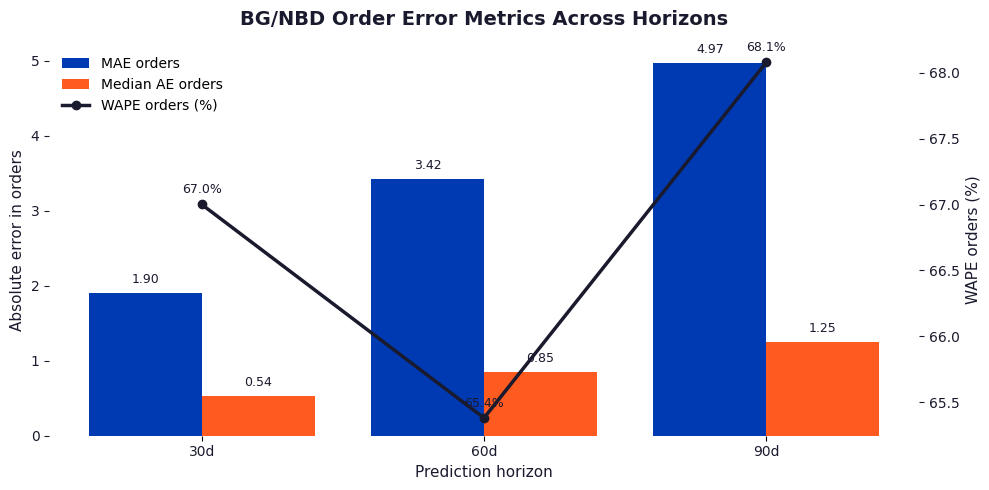

In [439]:
# ============================================================
# Plot 1: WAPE Orders + MAE Orders + Median AE Orders
# Clean dashboard-style visualization
# ============================================================

plot_df = activity_eval_df.copy()
plot_df["horizon_label"] = plot_df["horizon"].astype(str) + "d"
plot_df["wape_orders_pct"] = plot_df["wape_orders"] * 100

# ============================================================
# Brand palette
# ============================================================

BLUE = "#003AB2"
ORANGE = "#FF5A1F"
DARK = "#1A1A2E"
BG = "#F5F6FA"

# ============================================================
# Layout
# ============================================================

x = np.arange(len(plot_df))

# Grouped bar rule:
# - no gap inside group
# - gap between groups = 1/2 bar width
#
# If bar width = w
# distance between groups = 0.5w
#
# total group width = 2w
# center spacing = 2.5w
#
# => w = 1 / 2.5 = 0.4

width = 0.40

fig, ax1 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("white")
ax1.set_facecolor("white")

# ============================================================
# Grouped bars
# ============================================================

bar1 = ax1.bar(
    x - width / 2,
    plot_df["mae_orders"],
    width=width,
    color=BLUE,
    label="MAE orders"
)

bar2 = ax1.bar(
    x + width / 2,
    plot_df["median_ae_orders"],
    width=width,
    color=ORANGE,
    label="Median AE orders"
)

# ============================================================
# Left axis styling
# ============================================================

ax1.set_xlabel(
    "Prediction horizon",
    fontsize=11,
    color=DARK
)

ax1.set_ylabel(
    "Absolute error in orders",
    fontsize=11,
    color=DARK
)

ax1.set_xticks(x)
ax1.set_xticklabels(
    plot_df["horizon_label"],
    fontsize=10,
    color=DARK
)

ax1.tick_params(axis="y", labelsize=10, colors=DARK)

# Remove gridlines
ax1.grid(False)

# Remove borders/spines
for spine in ax1.spines.values():
    spine.set_visible(False)

# ============================================================
# Secondary axis
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    plot_df["wape_orders_pct"],
    color=DARK,
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="WAPE orders (%)"
)

ax2.set_ylabel(
    "WAPE orders (%)",
    fontsize=11,
    color=DARK
)

ax2.tick_params(axis="y", labelsize=10, colors=DARK)

# Remove secondary borders
for spine in ax2.spines.values():
    spine.set_visible(False)

# ============================================================
# Value labels — bars
# ============================================================

for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()

        ax1.annotate(
            f"{height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            color=DARK
        )

# ============================================================
# Value labels — line
# ============================================================

for i, val in enumerate(plot_df["wape_orders_pct"]):

    ax2.annotate(
        f"{val:.1f}%",
        xy=(x[i], val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=DARK
    )

# ============================================================
# Legend
# ============================================================

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    frameon=False,
    loc="upper left",
    fontsize=10
)

# ============================================================
# Title
# ============================================================

plt.title(
    "BG/NBD Order Error Metrics Across Horizons",
    fontsize=14,
    fontweight="bold",
    color=DARK,
    pad=14
)

plt.tight_layout()
plt.show()

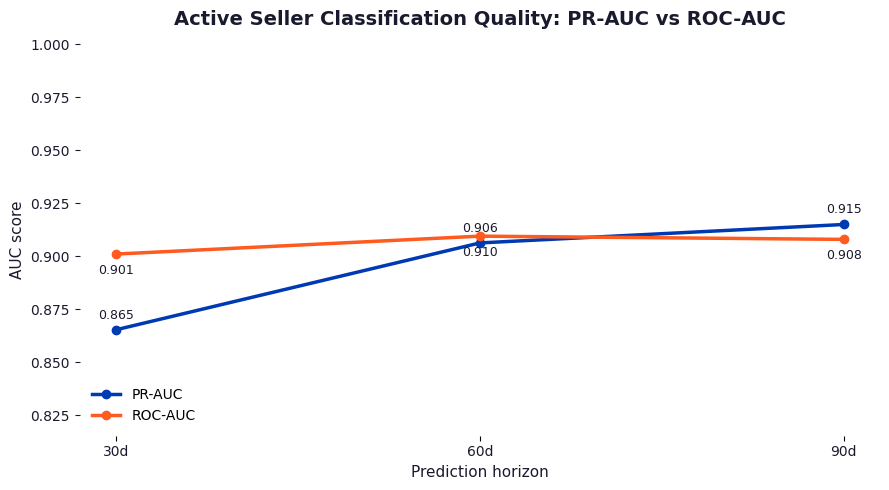

In [443]:
# ============================================================
# Plot 2: PR-AUC vs ROC-AUC across horizons
# Clean dashboard-style visualization
# ============================================================

plot_df = activity_eval_df.copy()
plot_df["horizon_label"] = plot_df["horizon"].astype(str) + "d"

# ============================================================
# Brand palette
# ============================================================

BLUE = "#003AB2"
ORANGE = "#FF5A1F"
DARK = "#1A1A2E"

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ============================================================
# Lines
# ============================================================

ax.plot(
    plot_df["horizon"],
    plot_df["pr_auc"],
    color=BLUE,
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="PR-AUC"
)

ax.plot(
    plot_df["horizon"],
    plot_df["roc_auc"],
    color=ORANGE,
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="ROC-AUC"
)

# ============================================================
# Value labels
# ============================================================

for _, row in plot_df.iterrows():

    # PR-AUC label
    ax.annotate(
        f"{row['pr_auc']:.3f}",
        xy=(row["horizon"], row["pr_auc"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=DARK
    )

    # ROC-AUC label
    ax.annotate(
        f"{row['roc_auc']:.3f}",
        xy=(row["horizon"], row["roc_auc"]),
        xytext=(0, -14),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=DARK
    )

# ============================================================
# Axes styling
# ============================================================

ax.set_xticks(plot_df["horizon"])
ax.set_xticklabels(
    plot_df["horizon_label"],
    fontsize=10,
    color=DARK
)

ax.tick_params(axis="y", labelsize=10, colors=DARK)

ax.set_xlabel(
    "Prediction horizon",
    fontsize=11,
    color=DARK
)

ax.set_ylabel(
    "AUC score",
    fontsize=11,
    color=DARK
)

# Better y-axis range
y_min = min(
    plot_df["pr_auc"].min(),
    plot_df["roc_auc"].min()
)

ax.set_ylim(max(0, y_min - 0.05), 1.0)

# ============================================================
# Remove gridlines & borders
# ============================================================

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# ============================================================
# Legend
# ============================================================

ax.legend(
    frameon=False,
    fontsize=10,
    loc="lower left"
)

# ============================================================
# Title
# ============================================================

plt.title(
    "Active Seller Classification Quality: PR-AUC vs ROC-AUC",
    fontsize=14,
    fontweight="bold",
    color=DARK,
    pad=14
)

plt.tight_layout()
plt.show()

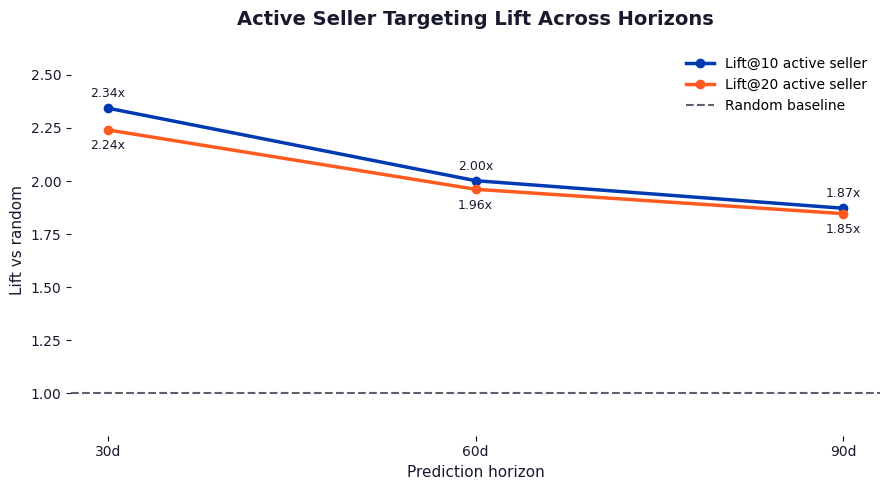

In [445]:
# ============================================================
# Plot 3: Lift@10 and Lift@20 active seller across horizons
# Clean dashboard-style visualization
# ============================================================

plot_df = activity_eval_df.copy()
plot_df["horizon_label"] = plot_df["horizon"].astype(str) + "d"

# ============================================================
# Brand palette
# ============================================================

BLUE = "#003AB2"
ORANGE = "#FF5A1F"
DARK = "#1A1A2E"

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ============================================================
# Lines
# ============================================================

ax.plot(
    plot_df["horizon"],
    plot_df["lift_top10_active"],
    color=BLUE,
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="Lift@10 active seller"
)

ax.plot(
    plot_df["horizon"],
    plot_df["lift_top20_active"],
    color=ORANGE,
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="Lift@20 active seller"
)

# ============================================================
# Random baseline
# ============================================================

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1.5,
    color=DARK,
    alpha=0.7,
    label="Random baseline"
)

# ============================================================
# Value labels
# ============================================================

for _, row in plot_df.iterrows():

    # Lift@10
    ax.annotate(
        f"{row['lift_top10_active']:.2f}x",
        xy=(row["horizon"], row["lift_top10_active"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=DARK
    )

    # Lift@20
    ax.annotate(
        f"{row['lift_top20_active']:.2f}x",
        xy=(row["horizon"], row["lift_top20_active"]),
        xytext=(0, -14),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=DARK
    )

# ============================================================
# Axes styling
# ============================================================

ax.set_xticks(plot_df["horizon"])

ax.set_xticklabels(
    plot_df["horizon_label"],
    fontsize=10,
    color=DARK
)

ax.tick_params(axis="y", labelsize=10, colors=DARK)

ax.set_xlabel(
    "Prediction horizon",
    fontsize=11,
    color=DARK
)

ax.set_ylabel(
    "Lift vs random",
    fontsize=11,
    color=DARK
)

# Better y-axis range
y_min = min(
    plot_df["lift_top10_active"].min(),
    plot_df["lift_top20_active"].min(),
    1.0
)

y_max = max(
    plot_df["lift_top10_active"].max(),
    plot_df["lift_top20_active"].max()
)

ax.set_ylim(
    max(0, y_min - 0.2),
    y_max + 0.3
)

# ============================================================
# Remove gridlines & borders
# ============================================================

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# ============================================================
# Legend
# ============================================================

ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper right"
)

# ============================================================
# Title
# ============================================================

plt.title(
    "Active Seller Targeting Lift Across Horizons",
    fontsize=14,
    fontweight="bold",
    color=DARK,
    pad=14
)

plt.tight_layout()
plt.show()

In [441]:
print("D1. Gamma-Gamma monetary metrics - all horizons")
display(monetary_eval_df)

D1. Gamma-Gamma monetary metrics - all horizons


,horizon,n_sellers_with_holdout_orders,wape_aov,spearman_aov,aov_error_pct,avg_pred_aov,avg_actual_aov,mae_aov,median_ae_aov
0,30,925,0.432503,0.744262,-0.015875,172.882025,175.670717,75.978164,26.786520
1,60,1108,0.415722,0.744659,-0.008838,179.799877,181.403050,75.413216,27.836649
2,90,1185,0.383021,0.768784,0.002208,188.523837,188.108503,72.049454,27.696675


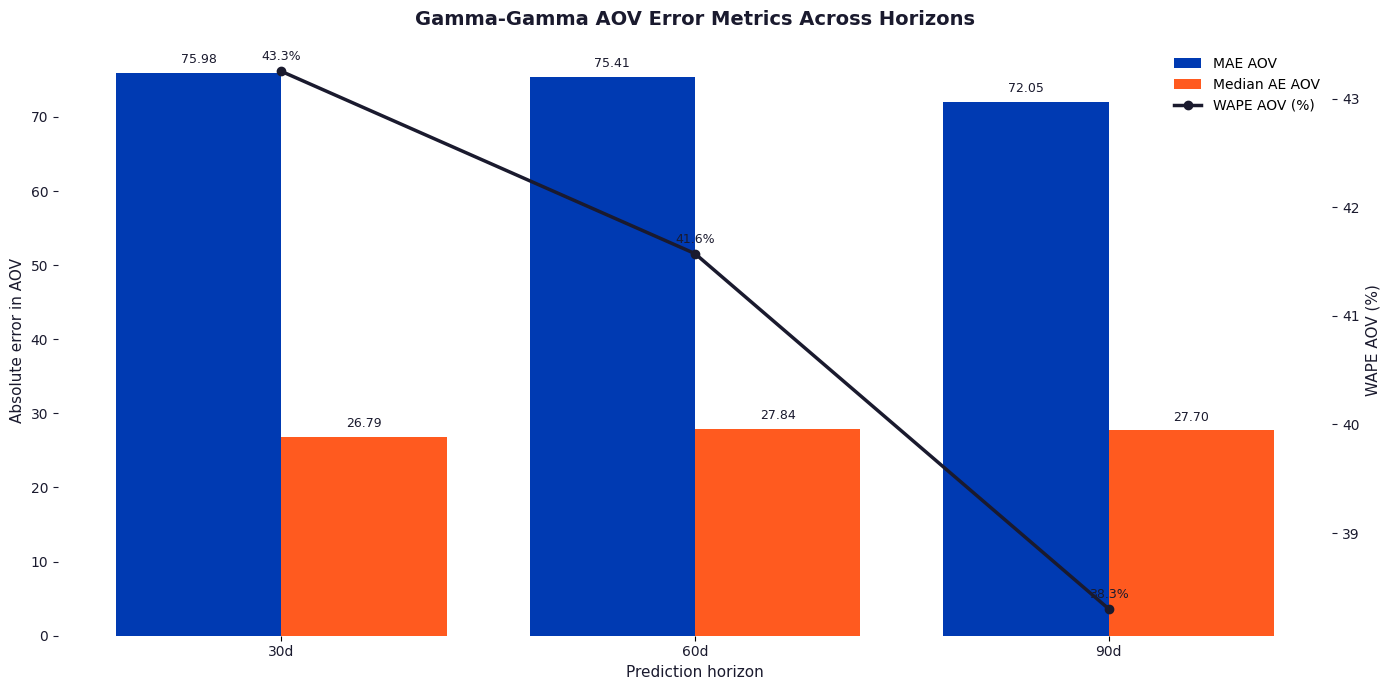

In [465]:
# ============================================================
# Plot 1: Gamma-Gamma AOV error metrics across horizons
# Clean dashboard-style visualization
# ============================================================

plot_df = monetary_eval_df.copy()
plot_df["horizon_label"] = plot_df["horizon"].astype(str) + "d"
plot_df["wape_aov_pct"] = plot_df["wape_aov"] * 100

# ============================================================
# Brand palette
# ============================================================

BLUE = "#003AB2"
ORANGE = "#FF5A1F"
DARK = "#1A1A2E"

# ============================================================
# Layout
# ============================================================

x = np.arange(len(plot_df))

# Grouped bar rule:
# - no gap inside group
# - gap between groups = 1/2 bar width

width = 0.40

fig, ax1 = plt.subplots(figsize=(14, 7))

fig.patch.set_facecolor("white")
ax1.set_facecolor("white")

# ============================================================
# Bars
# ============================================================

bar1 = ax1.bar(
    x - width / 2,
    plot_df["mae_aov"],
    width=width,
    color=BLUE,
    label="MAE AOV"
)

bar2 = ax1.bar(
    x + width / 2,
    plot_df["median_ae_aov"],
    width=width,
    color=ORANGE,
    label="Median AE AOV"
)

# ============================================================
# Left axis styling
# ============================================================

ax1.set_xlabel(
    "Prediction horizon",
    fontsize=11,
    color=DARK
)

ax1.set_ylabel(
    "Absolute error in AOV",
    fontsize=11,
    color=DARK
)

ax1.set_xticks(x)

ax1.set_xticklabels(
    plot_df["horizon_label"],
    fontsize=10,
    color=DARK
)

ax1.tick_params(axis="y", labelsize=10, colors=DARK)

# Remove gridlines
ax1.grid(False)

# Remove borders/spines
for spine in ax1.spines.values():
    spine.set_visible(False)

# ============================================================
# Secondary axis
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    plot_df["wape_aov_pct"],
    color=DARK,
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="WAPE AOV (%)"
)

ax2.set_ylabel(
    "WAPE AOV (%)",
    fontsize=11,
    color=DARK
)

ax2.tick_params(axis="y", labelsize=10, colors=DARK)

# Remove secondary borders
for spine in ax2.spines.values():
    spine.set_visible(False)

# ============================================================
# Value labels — bars
# ============================================================

for bars in [bar1, bar2]:

    for bar in bars:

        height = bar.get_height()

        ax1.annotate(
            f"{height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            color=DARK
        )

# ============================================================
# Value labels — line
# ============================================================

for i, val in enumerate(plot_df["wape_aov_pct"]):

    ax2.annotate(
        f"{val:.1f}%",
        xy=(x[i], val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=DARK
    )

# ============================================================
# Legend
# ============================================================

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    frameon=False,
    fontsize=10,
    loc="upper right"
)

# ============================================================
# Title
# ============================================================

plt.title(
    "Gamma-Gamma AOV Error Metrics Across Horizons",
    fontsize=14,
    fontweight="bold",
    color=DARK,
    pad=14
)

plt.tight_layout()
plt.show()

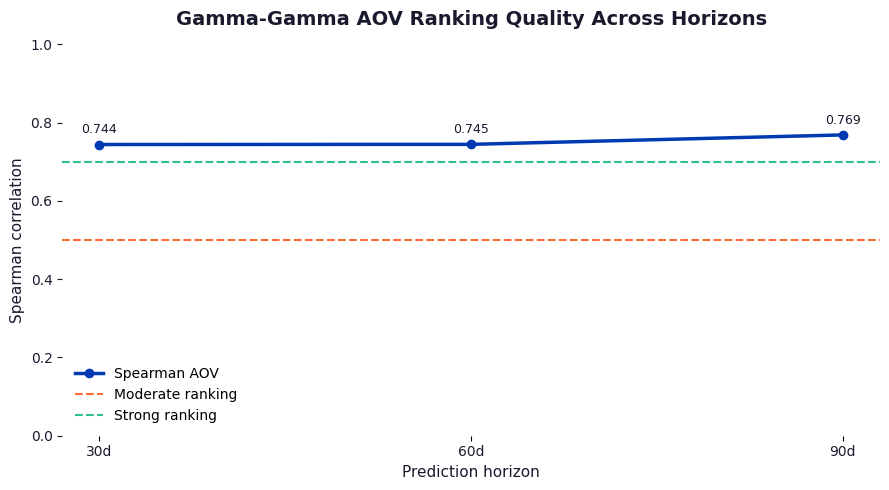

In [457]:
# ============================================================
# Plot 2: Spearman AOV with reference bands
# Clean dashboard-style visualization
# ============================================================

plot_df = monetary_eval_df.copy()
plot_df["horizon_label"] = plot_df["horizon"].astype(str) + "d"

# ============================================================
# Brand palette
# ============================================================

BLUE = "#003AB2"
ORANGE = "#FF5A1F"
GREEN = "#15B97F"
DARK = "#1A1A2E"

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ============================================================
# Main line
# ============================================================

ax.plot(
    plot_df["horizon"],
    plot_df["spearman_aov"],
    color=BLUE,
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="Spearman AOV"
)

# ============================================================
# Reference lines
# ============================================================

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    color=ORANGE,
    alpha=0.9,
    label="Moderate ranking"
)

ax.axhline(
    0.7,
    linestyle="--",
    linewidth=1.5,
    color=GREEN,
    alpha=0.9,
    label="Strong ranking"
)

# ============================================================
# Value labels
# ============================================================

for _, row in plot_df.iterrows():

    ax.annotate(
        f"{row['spearman_aov']:.3f}",
        xy=(row["horizon"], row["spearman_aov"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=DARK
    )

# ============================================================
# Axes styling
# ============================================================

ax.set_xticks(plot_df["horizon"])

ax.set_xticklabels(
    plot_df["horizon_label"],
    fontsize=10,
    color=DARK
)

ax.tick_params(axis="y", labelsize=10, colors=DARK)

ax.set_xlabel(
    "Prediction horizon",
    fontsize=11,
    color=DARK
)

ax.set_ylabel(
    "Spearman correlation",
    fontsize=11,
    color=DARK
)

ax.set_ylim(0, 1)

# ============================================================
# Remove gridlines & borders
# ============================================================

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# ============================================================
# Legend
# ============================================================

ax.legend(
    frameon=False,
    fontsize=10,
    loc="lower left"
)

# ============================================================
# Title
# ============================================================

plt.title(
    "Gamma-Gamma AOV Ranking Quality Across Horizons",
    fontsize=14,
    fontweight="bold",
    color=DARK,
    pad=14
)

plt.tight_layout()
plt.show()

In [447]:
combined_value_summary = value_eval_df[
    [
        "horizon",
        "wape_commission",
        "commission_error_pct",
        "spearman_rank_corr",
        "top10_value_capture",
        "top10_value_lift",
        "top20_value_capture",
        "top20_value_lift",
        "total_predicted_commission",
        "total_actual_commission",
        "mae_commission",
        "median_ae_commission"
    ]
].copy()

print("F1. Executive summary - combined value metrics")
display(combined_value_summary)

F1. Executive summary - combined value metrics


,horizon,wape_commission,commission_error_pct,spearman_rank_corr,top10_value_capture,top10_value_lift,top20_value_capture,top20_value_lift,total_predicted_commission,total_actual_commission,mae_commission,median_ae_commission
0,30,0.753131,0.006307,0.676113,0.649869,6.498688,0.799105,3.995525,134954.296903,134108.4720,44.929397,10.224363
1,60,0.708148,0.085466,0.727956,0.646146,6.461459,0.789152,3.945761,266554.125999,245566.5510,77.356519,17.656557
2,90,0.737758,0.166454,0.739985,0.639479,6.394787,0.780727,3.903635,395678.001414,339214.4085,111.324751,26.640194


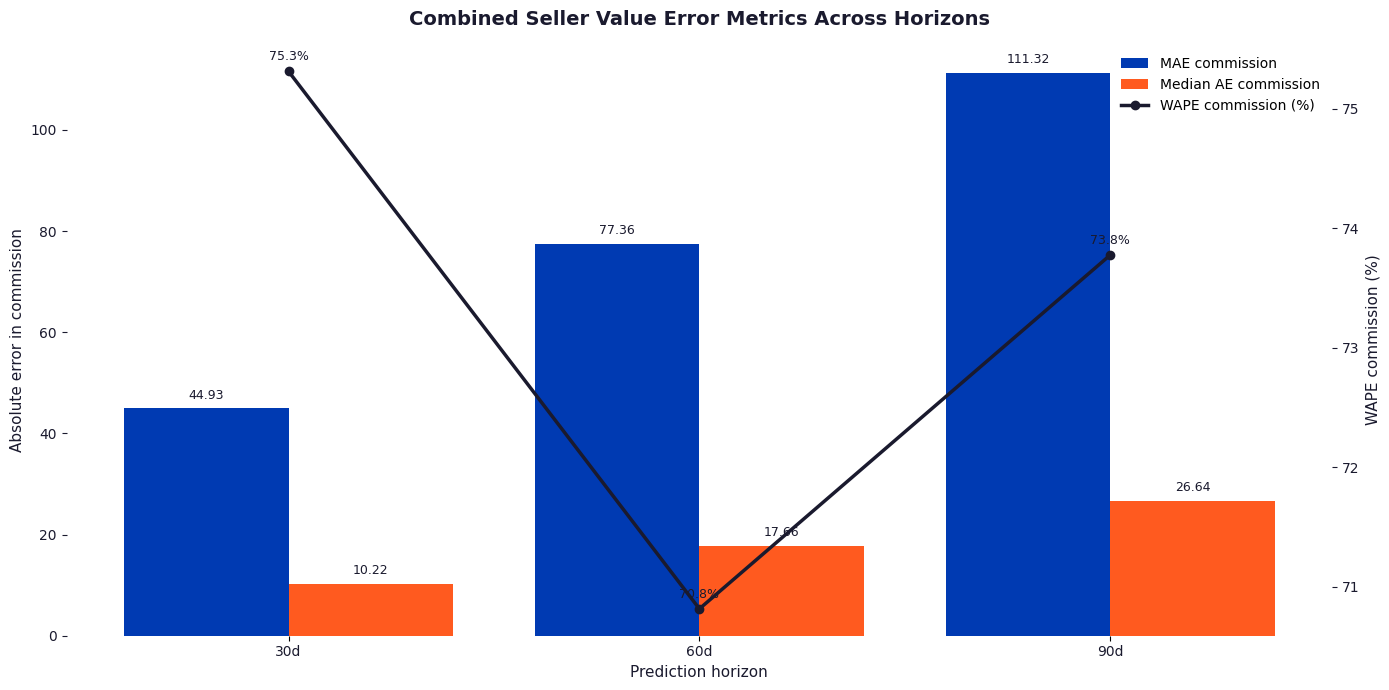

In [462]:
# ============================================================
# Plot 3: Combined value error metrics across horizons
# Clean dashboard-style visualization
# ============================================================

plot_df = combined_value_summary.copy()
plot_df["horizon_label"] = plot_df["horizon"].astype(str) + "d"
plot_df["wape_commission_pct"] = plot_df["wape_commission"] * 100

# ============================================================
# Brand palette
# ============================================================

BLUE = "#003AB2"
ORANGE = "#FF5A1F"
DARK = "#1A1A2E"

# ============================================================
# Layout
# ============================================================

x = np.arange(len(plot_df))

# Grouped bar rule:
# - no gap inside group
# - gap between groups = 1/2 bar width

width = 0.40

fig, ax1 = plt.subplots(figsize=(14, 7))

fig.patch.set_facecolor("white")
ax1.set_facecolor("white")

# ============================================================
# Bars
# ============================================================

bar1 = ax1.bar(
    x - width / 2,
    plot_df["mae_commission"],
    width=width,
    color=BLUE,
    label="MAE commission"
)

bar2 = ax1.bar(
    x + width / 2,
    plot_df["median_ae_commission"],
    width=width,
    color=ORANGE,
    label="Median AE commission"
)

# ============================================================
# Left axis styling
# ============================================================

ax1.set_xlabel(
    "Prediction horizon",
    fontsize=11,
    color=DARK
)

ax1.set_ylabel(
    "Absolute error in commission",
    fontsize=11,
    color=DARK
)

ax1.set_xticks(x)

ax1.set_xticklabels(
    plot_df["horizon_label"],
    fontsize=10,
    color=DARK
)

ax1.tick_params(axis="y", labelsize=10, colors=DARK)

# Remove gridlines
ax1.grid(False)

# Remove borders/spines
for spine in ax1.spines.values():
    spine.set_visible(False)

# ============================================================
# Secondary axis
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    plot_df["wape_commission_pct"],
    color=DARK,
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="WAPE commission (%)"
)

ax2.set_ylabel(
    "WAPE commission (%)",
    fontsize=11,
    color=DARK
)

ax2.tick_params(axis="y", labelsize=10, colors=DARK)

# Remove secondary borders
for spine in ax2.spines.values():
    spine.set_visible(False)

# ============================================================
# Value labels — bars
# ============================================================

for bars in [bar1, bar2]:

    for bar in bars:

        height = bar.get_height()

        ax1.annotate(
            f"{height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            color=DARK
        )

# ============================================================
# Value labels — line
# ============================================================

for i, val in enumerate(plot_df["wape_commission_pct"]):

    ax2.annotate(
        f"{val:.1f}%",
        xy=(x[i], val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=DARK
    )

# ============================================================
# Legend
# ============================================================

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    frameon=False,
    fontsize=10,
    loc="upper right"
)

# ============================================================
# Title
# ============================================================

plt.title(
    "Combined Seller Value Error Metrics Across Horizons",
    fontsize=14,
    fontweight="bold",
    color=DARK,
    pad=14
)

plt.tight_layout()
plt.show()

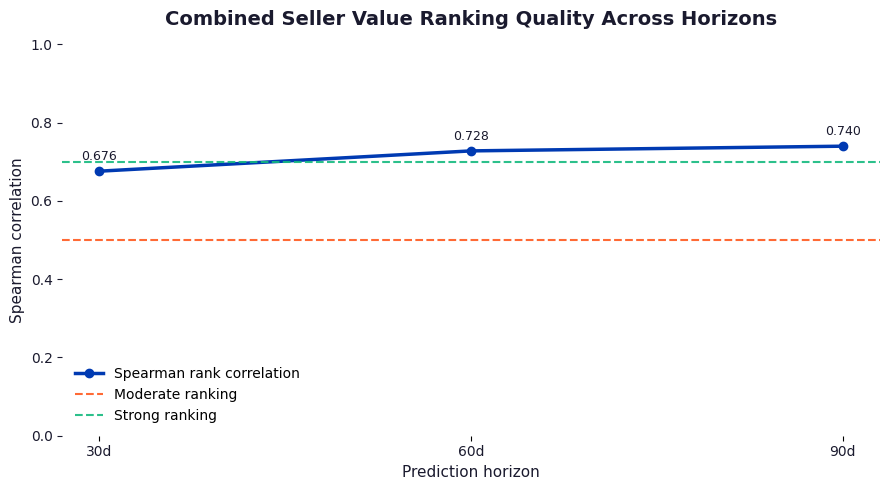

In [464]:
# ============================================================
# Plot 4: Spearman rank correlation for expected commission
# with reference lines
# Clean dashboard-style visualization
# ============================================================

plot_df = combined_value_summary.copy()
plot_df["horizon_label"] = plot_df["horizon"].astype(str) + "d"

# ============================================================
# Brand palette
# ============================================================

BLUE = "#003AB2"
ORANGE = "#FF5A1F"
GREEN = "#15B97F"
DARK = "#1A1A2E"

# ============================================================
# Figure
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ============================================================
# Main line
# ============================================================

ax.plot(
    plot_df["horizon"],
    plot_df["spearman_rank_corr"],
    color=BLUE,
    marker="o",
    linewidth=2.5,
    markersize=6,
    label="Spearman rank correlation"
)

# ============================================================
# Reference lines
# ============================================================

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    color=ORANGE,
    alpha=0.9,
    label="Moderate ranking"
)

ax.axhline(
    0.7,
    linestyle="--",
    linewidth=1.5,
    color=GREEN,
    alpha=0.9,
    label="Strong ranking"
)

# ============================================================
# Value labels
# ============================================================

for _, row in plot_df.iterrows():

    ax.annotate(
        f"{row['spearman_rank_corr']:.3f}",
        xy=(row["horizon"], row["spearman_rank_corr"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=DARK
    )

# ============================================================
# Axes styling
# ============================================================

ax.set_xticks(plot_df["horizon"])

ax.set_xticklabels(
    plot_df["horizon_label"],
    fontsize=10,
    color=DARK
)

ax.tick_params(axis="y", labelsize=10, colors=DARK)

ax.set_xlabel(
    "Prediction horizon",
    fontsize=11,
    color=DARK
)

ax.set_ylabel(
    "Spearman correlation",
    fontsize=11,
    color=DARK
)

ax.set_ylim(0, 1)

# ============================================================
# Remove gridlines & borders
# ============================================================

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# ============================================================
# Legend
# ============================================================

ax.legend(
    frameon=False,
    fontsize=10,
    loc="lower left"
)

# ============================================================
# Title
# ============================================================

plt.title(
    "Combined Seller Value Ranking Quality Across Horizons",
    fontsize=14,
    fontweight="bold",
    color=DARK,
    pad=14
)

plt.tight_layout()
plt.show()

## **PLOTS**

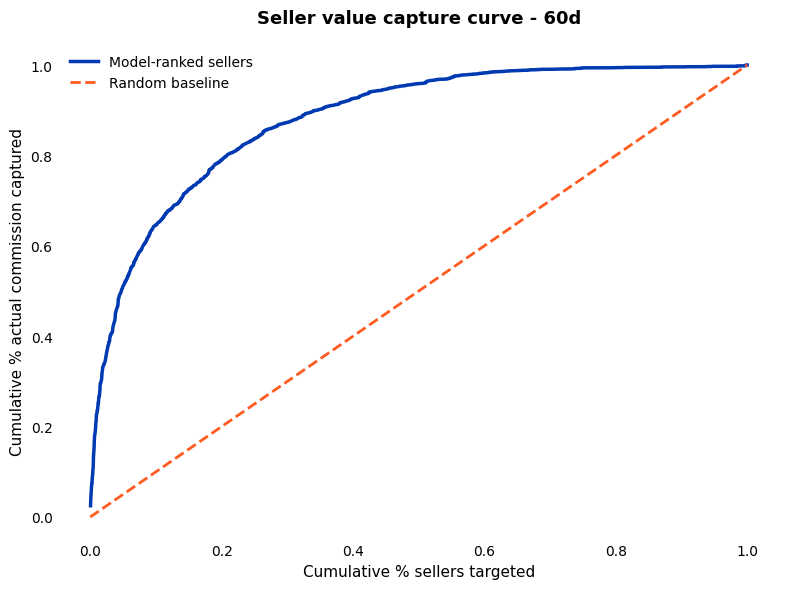

In [418]:
# ------------------------------------------------------------
# Plot 1: Value capture curve
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

# Main curve
ax.plot(
    value_curve_eval["cum_seller_pct"],
    value_curve_eval["cum_actual_value_pct"],
    color="#003AB2",          # Blue Dark
    linewidth=2.5,
    label="Model-ranked sellers"
)

# Random baseline
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    color="#FF5A1F",          # Olist Orange
    label="Random baseline"
)

# Labels
ax.set_xlabel("Cumulative % sellers targeted", fontsize=11)
ax.set_ylabel("Cumulative % actual commission captured", fontsize=11)

# Title
ax.set_title(
    f"Seller value capture curve - {H_EVAL}d",
    fontsize=13,
    fontweight="bold",
    pad=14
)

# Remove gridlines
ax.grid(False)

# Remove all borders/spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Cleaner ticks
ax.tick_params(axis="both", length=0, labelsize=10)

# Legend
ax.legend(frameon=False, fontsize=10)

# Background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
# save_current_plot(f"01_value_capture_curve_{H_EVAL}d.png")
plt.show()

**What does this plot show?**  
The curve shows how much `actual_commission` is captured when selecting the top X% of sellers ranked by `expected_commission`. The random baseline represents the scenario where sellers are selected randomly.

**Business interpretation**  
This is the most important plot for evaluating the model’s ability to **rank sellers by future value**. The plot does not require the model to predict the exact commission for every seller; instead, it evaluates whether the model correctly places high-value sellers at the top of the ranking.

**Key findings and insights**  
The model-ranked seller curve lies far above the random baseline. This demonstrates that the model has very strong ranking capability: by focusing on only a small proportion of sellers at the top of the list, the business can already capture a large share of the actual commission.

From a business perspective, this is the strongest evidence supporting the use of the model for decisions such as: selecting sellers for Seller Success support, prioritizing operational assistance, targeting sellers for campaigns, or identifying the seller groups with the highest ROI. The core message is not that “the model predicts the exact commission of each seller perfectly,” but rather that **the model helps concentrate resources on the sellers who generate the majority of business value**.

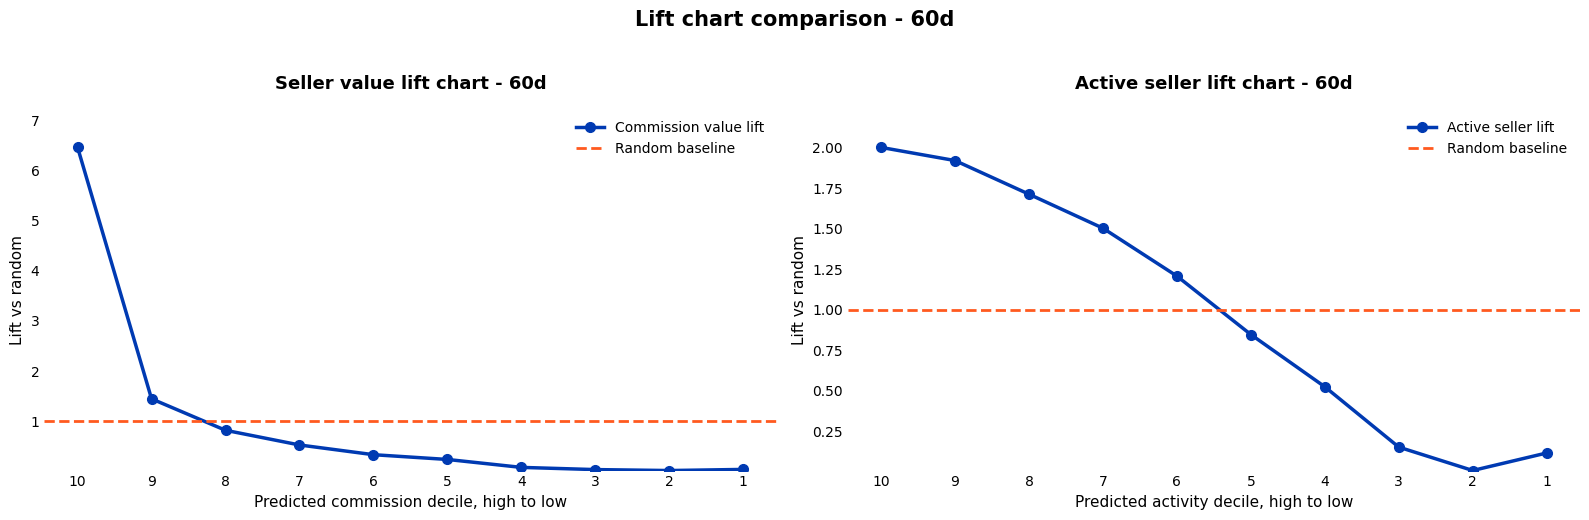

In [420]:
# ------------------------------------------------------------
# Combined Plot 2:
# Seller value lift + Active seller lift
# Different y-axis ranges
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
    sharey=False          # IMPORTANT
)

# ============================================================
# Left chart: Seller value lift
# ============================================================

ax = axes[0]

ax.plot(
    value_lift_eval["decile"].astype(str),
    value_lift_eval["value_lift"],
    color="#003AB2",
    linewidth=2.5,
    marker="o",
    markersize=7,
    label="Commission value lift"
)

ax.axhline(
    1,
    linestyle="--",
    linewidth=2,
    color="#FF5A1F",
    label="Random baseline"
)

# Dynamic y range
left_ymax = value_lift_eval["value_lift"].max() * 1.12
left_ymin = min(0.8, value_lift_eval["value_lift"].min() * 0.95)

ax.set_ylim(left_ymin, left_ymax)

ax.set_xlabel(
    "Predicted commission decile, high to low",
    fontsize=11
)

ax.set_ylabel(
    "Lift vs random",
    fontsize=11
)

ax.set_title(
    f"Seller value lift chart - {H_EVAL}d",
    fontsize=13,
    fontweight="bold",
    pad=14
)

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis="both",
    length=0,
    labelsize=10
)

ax.legend(
    frameon=False,
    fontsize=10
)

# ============================================================
# Right chart: Active seller lift
# ============================================================

ax = axes[1]

ax.plot(
    active_lift_eval["decile"].astype(str),
    active_lift_eval["lift"],
    color="#003AB2",
    linewidth=2.5,
    marker="o",
    markersize=7,
    label="Active seller lift"
)

ax.axhline(
    1,
    linestyle="--",
    linewidth=2,
    color="#FF5A1F",
    label="Random baseline"
)

# Dynamic y range
right_ymax = active_lift_eval["lift"].max() * 1.12
right_ymin = min(0.8, active_lift_eval["lift"].min() * 0.95)

ax.set_ylim(right_ymin, right_ymax)

ax.set_xlabel(
    "Predicted activity decile, high to low",
    fontsize=11
)

ax.set_ylabel(
    "Lift vs random",
    fontsize=11
)

ax.set_title(
    f"Active seller lift chart - {H_EVAL}d",
    fontsize=13,
    fontweight="bold",
    pad=14
)

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(
    axis="both",
    length=0,
    labelsize=10
)

ax.legend(
    frameon=False,
    fontsize=10
)

# ============================================================
# Shared styling
# ============================================================

fig.patch.set_facecolor("white")

for ax in axes:
    ax.set_facecolor("white")

fig.suptitle(
    f"Lift chart comparison - {H_EVAL}d",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

# save_current_plot(f"02_combined_lift_charts_{H_EVAL}d.png")

plt.show()

***Seller value lift chart by expected commission***

**What does this plot show?**  
Each decile represents a 10% group of sellers ranked by `expected_commission`. The lift indicates how many times higher or lower the group’s average actual commission is compared to the overall seller average.

**Business interpretation**  
This plot shows whether the model creates a clear value segmentation across sellers. A strong model should produce high lift in the top deciles, followed by a gradual decline in lower deciles.

**Key findings and insights**  
The top decile has a very high value lift, while the following deciles decline rapidly. This indicates that seller value is not evenly distributed, but instead highly concentrated among the top-ranked sellers. The model successfully captures this concentration pattern. This is a strong signal that the model has **high reliability for ranking and targeting**, especially when business resources are limited to only the top 10–20% of sellers.

From a business perspective, this plot suggests that broad campaigns across the entire seller base are inefficient. Instead, businesses should design tiered strategies: the top decile may receive proactive support or stronger operational incentives; the second decile may receive lighter campaigns; and lower deciles may be managed through automation or lower-cost rule-based approaches. The plot also clearly quantifies that **seller support resources should be concentrated on top-ranked sellers**, since the expected return is significantly higher than random allocation.

***Active seller lift chart***

**What does this plot show?**  
This is a lift chart by `activity_score` decile, measuring the active rate of each seller group relative to the average active rate.

**Business interpretation**  
This plot evaluates the model’s ability to identify sellers who are likely to generate orders during the holdout period.

**Key findings and insights**  
High lift in the top deciles and progressively lower lift in later deciles indicate that the model effectively distinguishes active sellers from inactive ones. However, activity lift is usually lower than value lift because “being active” is a more saturated problem: many sellers may generate at least one order, but only a small subset contributes significant commission.

From a business perspective, this plot is particularly useful when the objective is **seller activation** or **seller churn prevention**. If the campaign goal is simply to encourage sellers to return and place orders, activity lift is an appropriate metric. However, if the goal is to maximize commission revenue, value capture and value lift should be prioritized over active lift, since an active seller with one small order may be less valuable than a less active seller with very high GMV or order value.

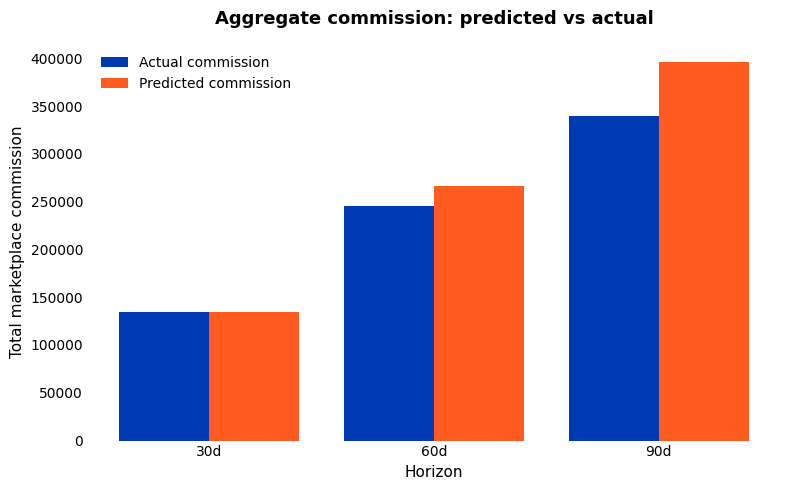

In [421]:
# ------------------------------------------------------------
# Plot 3: Aggregate commission predicted vs actual
# ------------------------------------------------------------

plot_agg = aggregate_eval_df.copy()

x = np.arange(len(plot_agg))

# Grouped bar chart:
# - No gap inside each group
# - Gap between groups = 1/2 bar width
bar_width = 0.4

fig, ax = plt.subplots(figsize=(8, 5))

# Actual commission
ax.bar(
    x - bar_width / 2,
    plot_agg["actual_commission"],
    width=bar_width,
    color="#003AB2",          # Blue Dark
    label="Actual commission"
)

# Predicted commission
ax.bar(
    x + bar_width / 2,
    plot_agg["pred_commission"],
    width=bar_width,
    color="#FF5A1F",          # Olist Orange
    label="Predicted commission"
)

# X ticks
ax.set_xticks(x)
ax.set_xticklabels(
    plot_agg["horizon"].astype(str) + "d",
    fontsize=10
)

# Labels
ax.set_xlabel("Horizon", fontsize=11)
ax.set_ylabel("Total marketplace commission", fontsize=11)

# Title
ax.set_title(
    "Aggregate commission: predicted vs actual",
    fontsize=13,
    fontweight="bold",
    pad=14
)

# Remove gridlines
ax.grid(False)

# Remove borders/spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Cleaner ticks
ax.tick_params(
    axis="both",
    length=0,
    labelsize=10
)

# Legend
ax.legend(
    frameon=False,
    fontsize=10
)

# Background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
# save_current_plot("03_aggregate_commission.png")
plt.show()

**What does this plot show?**  
This plot compares total predicted commission and total actual commission across the 30-day, 60-day, and 90-day horizons.

**Business interpretation**  
This plot evaluates the model’s ability to serve as a **forecasting tool for total commission revenue** across the seller base.

**Key findings and insights**  
The 30-day results are very close to the actual values, indicating that the model is highly reliable for short-term forecasting. However, at the 60-day and 90-day horizons, predicted commission becomes increasingly higher than actual commission. This does not reduce the value of the model, but it does indicate that the model becomes **overly optimistic at longer horizons**.

From a modeling perspective, this error suggests that the BG/NBD assumption, that sellers continue generating orders at a relatively stable rate over time, may be somewhat too strong for real-world marketplace seller behavior. From a business perspective, the 30-day forecast can be used directly for short-term planning, but the 60-day and 90-day forecasts should not be treated as guaranteed revenue commitments. Instead, businesses should apply calibration factors, account for seasonality effects, or present long-term forecasts as “expected potential” rather than precise revenue predictions.

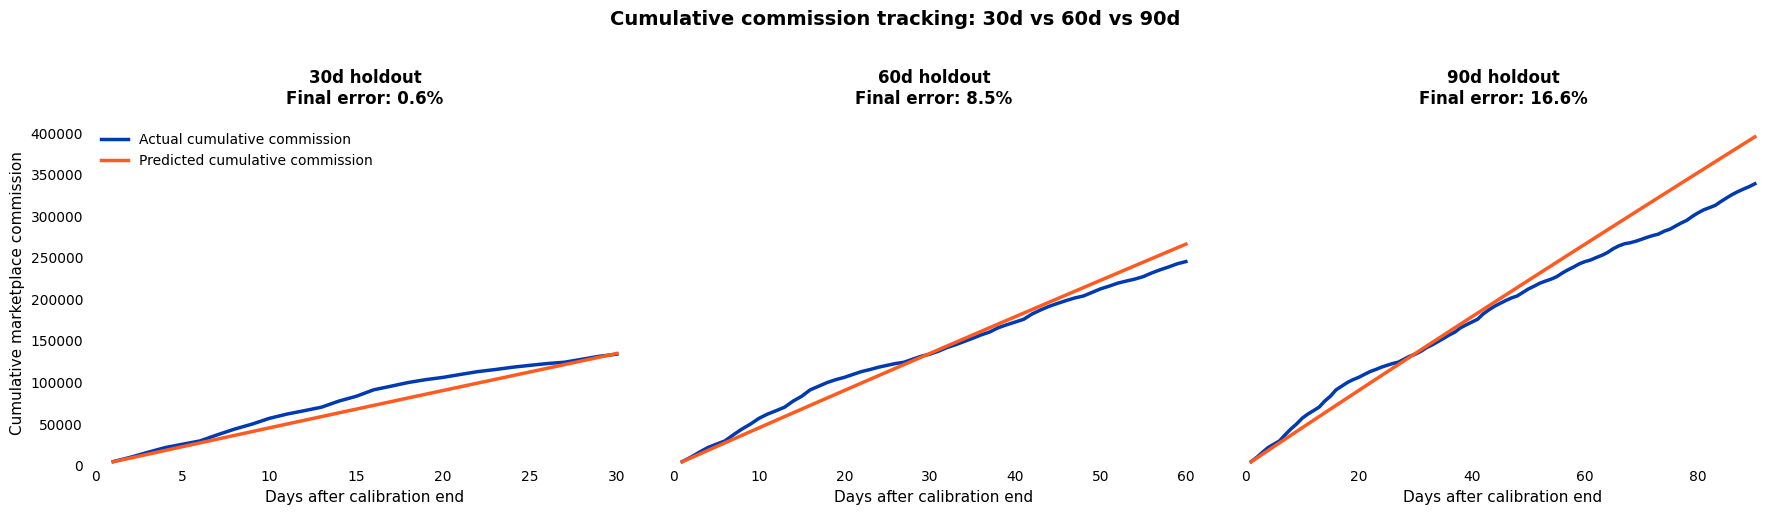

In [422]:
# ------------------------------------------------------------
# Plot 4: Cumulative commission 30d / 60d / 90d, same y-axis
# ------------------------------------------------------------

commission_ymax = max(
    max(df["actual_commission_cum"].max(), df["pred_commission_cum"].max())
    for df in daily_tracking_by_horizon.values()
) * 1.05

fig, axes = plt.subplots(
    1,
    len(HORIZONS_TO_PLOT),
    figsize=(18, 5),
    sharey=True
)

if len(HORIZONS_TO_PLOT) == 1:
    axes = [axes]

for ax, h in zip(axes, HORIZONS_TO_PLOT):

    df = daily_tracking_by_horizon[h]

    final_actual = df["actual_commission_cum"].iloc[-1]
    final_pred = df["pred_commission_cum"].iloc[-1]
    final_error_pct = safe_pct_error(final_pred, final_actual)

    # Actual line
    ax.plot(
        df["day"],
        df["actual_commission_cum"],
        color="#003AB2",          # Blue Dark
        linewidth=2.5,
        label="Actual cumulative commission"
    )

    # Predicted line
    ax.plot(
        df["day"],
        df["pred_commission_cum"],
        color="#FF5A1F",          # Olist Orange
        linewidth=2.5,
        label="Predicted cumulative commission"
    )

    # Subplot title
    ax.set_title(
        f"{h}d holdout\nFinal error: {final_error_pct:.1%}",
        fontsize=12,
        fontweight="bold",
        pad=12
    )

    # Axis labels
    ax.set_xlabel(
        "Days after calibration end",
        fontsize=11
    )

    # Shared y range
    ax.set_ylim(0, commission_ymax)

    # Remove gridlines
    ax.grid(False)

    # Remove borders/spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Cleaner ticks
    ax.tick_params(
        axis="both",
        length=0,
        labelsize=10
    )

# Shared y label
axes[0].set_ylabel(
    "Cumulative marketplace commission",
    fontsize=11
)

# Legend only once
axes[0].legend(
    loc="upper left",
    frameon=False,
    fontsize=10
)

# Main title
fig.suptitle(
    "Cumulative commission tracking: 30d vs 60d vs 90d",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

# Background
fig.patch.set_facecolor("white")

for ax in axes:
    ax.set_facecolor("white")

plt.tight_layout()
# save_current_plot("04_cumulative_commission_30_60_90_same_y.png")
plt.show()

**What does this plot show?**  
This plot tracks cumulative commission over time during the holdout period, comparing actual cumulative commission with predicted cumulative commission on a daily basis.

**Business interpretation**  
This plot evaluates whether the model correctly captures the **growth trajectory over time**, rather than only matching the final total at the end of the forecast horizon.

**Key findings and insights**  
At the 30-day horizon, the two curves almost converge by the end of the period, indicating that the model performs well for short-term total commission forecasting. However, actual commission grows faster than predicted during the early stage, while the predicted curve catches up later. At the 60-day and 90-day horizons, the predicted curve continues to increase steadily and eventually exceeds the actual curve around the middle of the period. The relatively straight predicted curve is not abnormal; it is a characteristic of the BG/NBD model when seasonality, campaigns, sale events, or day-of-week effects are not included.

From a reliability perspective, this plot shows that the model is trustworthy for **30-day aggregate commission forecasting**, but not yet sufficient for predicting daily cashflow patterns or campaign-driven fluctuations. From a business perspective, the model is suitable for high-level 30-day planning. However, if the objective is daily cashflow forecasting, workforce allocation by day, or measuring the impact of sales events, additional seasonality and daily adjustment components are needed. For the 60-day and 90-day horizons, the predicted curve should be interpreted more as an upper-bound estimate than as a fully calibrated forecast.

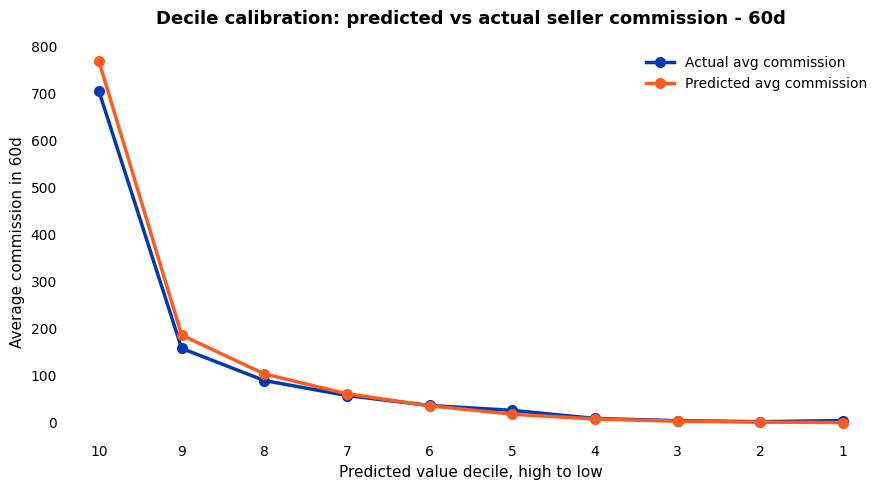

In [423]:
# ------------------------------------------------------------
# Plot 5: Decile calibration by expected commission
# ------------------------------------------------------------

plot_decile = decile_eval.copy()

x = np.arange(len(plot_decile))

fig, ax = plt.subplots(figsize=(9, 5))

# Actual average commission
ax.plot(
    x,
    plot_decile["avg_actual"],
    color="#003AB2",          # Blue Dark
    linewidth=2.5,
    marker="o",
    markersize=7,
    label="Actual avg commission"
)

# Predicted average commission
ax.plot(
    x,
    plot_decile["avg_pred"],
    color="#FF5A1F",          # Olist Orange
    linewidth=2.5,
    marker="o",
    markersize=7,
    label="Predicted avg commission"
)

# X ticks
ax.set_xticks(x)
ax.set_xticklabels(
    plot_decile["decile"].astype(str),
    fontsize=10
)

# Labels
ax.set_xlabel(
    "Predicted value decile, high to low",
    fontsize=11
)

ax.set_ylabel(
    f"Average commission in {H_EVAL}d",
    fontsize=11
)

# Title
ax.set_title(
    f"Decile calibration: predicted vs actual seller commission - {H_EVAL}d",
    fontsize=13,
    fontweight="bold",
    pad=14
)

# Remove gridlines
ax.grid(False)

# Remove borders/spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Cleaner ticks
ax.tick_params(
    axis="both",
    length=0,
    labelsize=10
)

# Legend
ax.legend(
    frameon=False,
    fontsize=10
)

# Background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
# save_current_plot(f"05_decile_commission_calibration_{H_EVAL}d.png")
plt.show()

**What does this plot show?**  
Sellers are ranked by `expected_commission`, divided into deciles, and then the predicted average commission is compared with the actual average commission for each decile.

**Business interpretation**  
This plot evaluates two aspects simultaneously:  
1. Whether the model performs **correct ranking**: do higher deciles actually generate higher commission than lower deciles?  
2. Whether the model is **well calibrated in magnitude**: are predicted values close to actual values within each decile?

**Key findings and insights**  
Actual commission decreases clearly from higher to lower deciles, indicating that the model segments sellers effectively. This is a very positive signal regarding the model’s reliability for ranking purposes. However, in some deciles, especially the top deciles, predicted commission tends to deviate from actual commission. This suggests that the model is **better at ranking sellers than at producing perfectly accurate absolute forecasts**.

From a business perspective, this plot supports using the model to segment sellers into actionable groups such as Top Sellers, Growth Sellers, and Low-Priority Sellers.

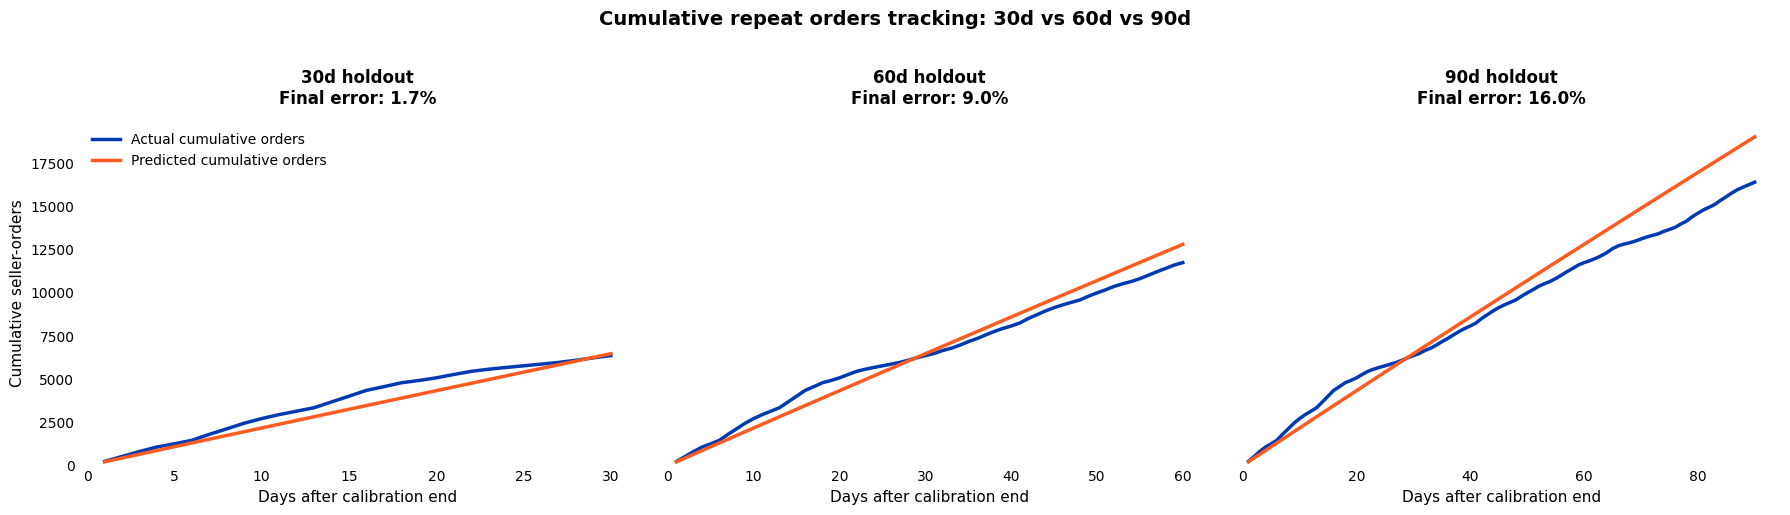

In [424]:
# ------------------------------------------------------------
# Plot 6: Cumulative orders 30d / 60d / 90d, same y-axis
# ------------------------------------------------------------

orders_ymax = max(
    max(df["actual_orders_cum"].max(), df["pred_orders_cum"].max())
    for df in daily_tracking_by_horizon.values()
) * 1.05

fig, axes = plt.subplots(
    1,
    len(HORIZONS_TO_PLOT),
    figsize=(18, 5),
    sharey=True
)

if len(HORIZONS_TO_PLOT) == 1:
    axes = [axes]

for ax, h in zip(axes, HORIZONS_TO_PLOT):

    df = daily_tracking_by_horizon[h]

    final_actual = df["actual_orders_cum"].iloc[-1]
    final_pred = df["pred_orders_cum"].iloc[-1]
    final_error_pct = safe_pct_error(final_pred, final_actual)

    # Actual cumulative orders
    ax.plot(
        df["day"],
        df["actual_orders_cum"],
        color="#003AB2",          # Blue Dark
        linewidth=2.5,
        label="Actual cumulative orders"
    )

    # Predicted cumulative orders
    ax.plot(
        df["day"],
        df["pred_orders_cum"],
        color="#FF5A1F",          # Olist Orange
        linewidth=2.5,
        label="Predicted cumulative orders"
    )

    # Subplot title
    ax.set_title(
        f"{h}d holdout\nFinal error: {final_error_pct:.1%}",
        fontsize=12,
        fontweight="bold",
        pad=12
    )

    # Axis labels
    ax.set_xlabel(
        "Days after calibration end",
        fontsize=11
    )

    # Shared y range
    ax.set_ylim(0, orders_ymax)

    # Remove gridlines
    ax.grid(False)

    # Remove borders/spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Cleaner ticks
    ax.tick_params(
        axis="both",
        length=0,
        labelsize=10
    )

# Shared y label
axes[0].set_ylabel(
    "Cumulative seller-orders",
    fontsize=11
)

# Legend only once
axes[0].legend(
    loc="upper left",
    frameon=False,
    fontsize=10
)

# Main title
fig.suptitle(
    "Cumulative repeat orders tracking: 30d vs 60d vs 90d",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

# Background
fig.patch.set_facecolor("white")

for ax in axes:
    ax.set_facecolor("white")

plt.tight_layout()
# save_current_plot("06_cumulative_orders_30_60_90_same_y.png")
plt.show()

**What does this plot show?**  
This plot tracks cumulative seller-orders over time on a daily basis, comparing actual orders with predicted orders.

**Business interpretation**  
This plot directly evaluates the BG/NBD component, since BG/NBD is specifically designed to forecast future order frequency.

**Key findings and insights**  
The order pattern is almost identical to the commission pattern: the 30-day horizon fits well, while the 60-day and 90-day horizons begin to over-forecast. This is a very important finding because it indicates that the primary source of commission forecasting error comes from **order count prediction**, rather than from the Gamma-Gamma/AOV component. If AOV estimation were the main issue, the commission plot would diverge from the order plot pattern; however, the two patterns are highly consistent here.

From a reliability perspective, BG/NBD performs well for short-term activity forecasting but becomes somewhat optimistic over longer horizons. From a business perspective, the model is suitable for forecasting order activity within a 30-day window or ranking sellers by activity potential. However, if it is used for 60–90 day operational capacity forecasting, additional adjustments are needed, such as seasonality modeling, seller churn thresholds, campaign calendars, or horizon-specific calibration factors.

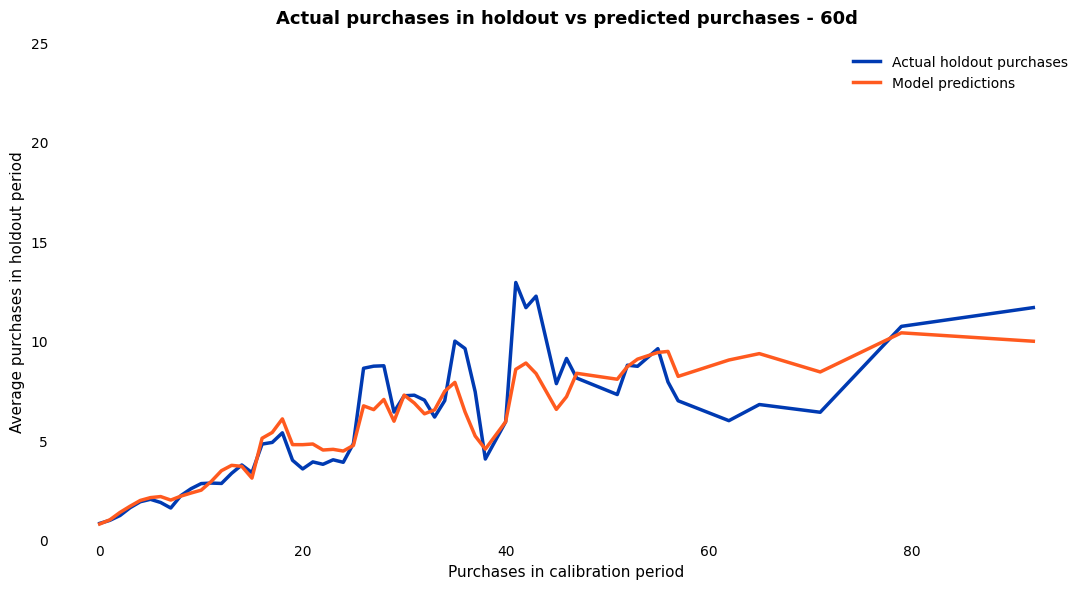

In [425]:
# ------------------------------------------------------------
# Plot 7: Conditional expectation by exact calibration frequency
# ------------------------------------------------------------

smooth_plot = purchase_holdout_vs_pred.copy()

smooth_plot["actual_smooth"] = (
    smooth_plot["actual_purchases_holdout"]
    .rolling(window=3, min_periods=1, center=True)
    .mean()
)

smooth_plot["pred_smooth"] = (
    smooth_plot["model_predictions"]
    .rolling(window=3, min_periods=1, center=True)
    .mean()
)

fig, ax = plt.subplots(figsize=(11, 6))

# Actual purchases
ax.plot(
    smooth_plot["frequency_int"],
    smooth_plot["actual_smooth"],
    color="#003AB2",          # Blue Dark
    linewidth=2.5,
    label="Actual holdout purchases"
)

# Predicted purchases
ax.plot(
    smooth_plot["frequency_int"],
    smooth_plot["pred_smooth"],
    color="#FF5A1F",          # Olist Orange
    linewidth=2.5,
    label="Model predictions"
)

# Labels
ax.set_xlabel(
    "Purchases in calibration period",
    fontsize=11
)

ax.set_ylabel(
    "Average purchases in holdout period",
    fontsize=11
)

# Title
ax.set_title(
    f"Actual purchases in holdout vs predicted purchases - {H_EVAL}d",
    fontsize=13,
    fontweight="bold",
    pad=14
)

# Remove gridlines
ax.grid(False)

# Remove borders/spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Cleaner ticks
ax.tick_params(
    axis="both",
    length=0,
    labelsize=10
)

# Legend
ax.legend(
    frameon=False,
    fontsize=10
)

# Background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Set y-axis range
ax.set_ylim(0, 25)

plt.tight_layout()
# save_current_plot(f"07_actual_holdout_vs_predicted_purchases_{H_EVAL}d.png")
plt.show()

**What does this plot show?**  
Sellers are grouped by the number of purchases made during the calibration period. For each frequency level, the plot compares the average actual purchases in the holdout period with the average predicted purchases.

**Business interpretation**  
This is a conditional expectation plot, closely aligned with how BG/NBD models are evaluated in academic literature. It tests whether, for sellers with the same historical purchase frequency, the model correctly predicts their average future behavior.

**Key findings and insights**  
The model successfully captures the main behavioral trend: sellers with higher calibration-period frequency generally produce higher holdout purchases. This indicates that BG/NBD has learned the core relationship between historical and future activity. However, in the high-frequency region, actual values fluctuate more strongly than predicted values. This does not necessarily mean the model is fundamentally incorrect; high-frequency groups usually contain fewer sellers and are therefore more sensitive to outliers or exceptionally large sellers. The predicted line appears smoother because it represents the average probabilistic expectation.

From a reliability perspective, this plot shows that the model is trustworthy for capturing **average behavioral trends**, especially among sellers with sufficiently rich transaction histories. However, for extremely large or highly unusual sellers, uncertainty becomes higher. Therefore, the model is best used for seller ranking and segmentation, while very large sellers should still be reviewed separately using business rules or account-manager knowledge, since a small number of outlier sellers can disproportionately influence total GMV and commission.

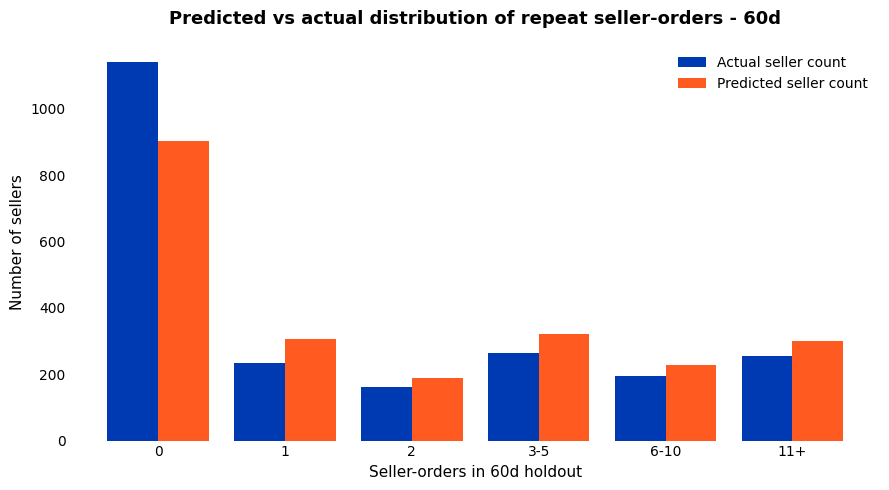

In [426]:
# ------------------------------------------------------------
# Plot 8: Predicted vs actual holdout frequency distribution
# ------------------------------------------------------------

freq_dist = frequency_distribution_eval.copy()

x = np.arange(len(freq_dist))

# Grouped bar chart:
# - No gap inside each group
# - Gap between groups = 1/2 bar width
bar_width = 0.4

fig, ax = plt.subplots(figsize=(9, 5))

# Actual seller count
ax.bar(
    x - bar_width / 2,
    freq_dist["actual_seller_count"],
    width=bar_width,
    color="#003AB2",          # Blue Dark
    label="Actual seller count"
)

# Predicted seller count
ax.bar(
    x + bar_width / 2,
    freq_dist["predicted_seller_count"],
    width=bar_width,
    color="#FF5A1F",          # Olist Orange
    label="Predicted seller count"
)

# X ticks
ax.set_xticks(x)

ax.set_xticklabels(
    freq_dist["order_bucket"].astype(str),
    fontsize=10
)

# Labels
ax.set_xlabel(
    f"Seller-orders in {H_EVAL}d holdout",
    fontsize=11
)

ax.set_ylabel(
    "Number of sellers",
    fontsize=11
)

# Title
ax.set_title(
    f"Predicted vs actual distribution of repeat seller-orders - {H_EVAL}d",
    fontsize=13,
    fontweight="bold",
    pad=14
)

# Remove gridlines
ax.grid(False)

# Remove borders/spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Cleaner ticks
ax.tick_params(
    axis="both",
    length=0,
    labelsize=10
)

# Legend
ax.legend(
    frameon=False,
    fontsize=10
)

# Background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
# save_current_plot(f"08_frequency_distribution_{H_EVAL}d.png")
plt.show()

**What does this plot show?**  
This plot compares the number of sellers within each holdout order bucket: 0, 1, 2, 3–5, 6–10, and 11+ orders.

**Business interpretation**  
This plot evaluates whether the model correctly reproduces the overall activity distribution, especially the group of sellers who generate no orders during the holdout period.

**Key findings and insights**  
The model predicts too few sellers in the 0-order bucket and too many sellers in the buckets with positive orders. This is a very important diagnostic result: the model is somewhat overestimating the likelihood that sellers remain active over time. This directly explains why cumulative orders and commission become over-forecasted at the 60-day and 90-day horizons.

From a reliability perspective, the model’s main weakness lies in distinguishing between sellers who “still have potential but remain inactive” and sellers who are effectively inactive or churned. From a business perspective, caution is needed when using the model to target seller activation campaigns, especially for sellers with positive expected value but a high real-world probability of generating no future orders.

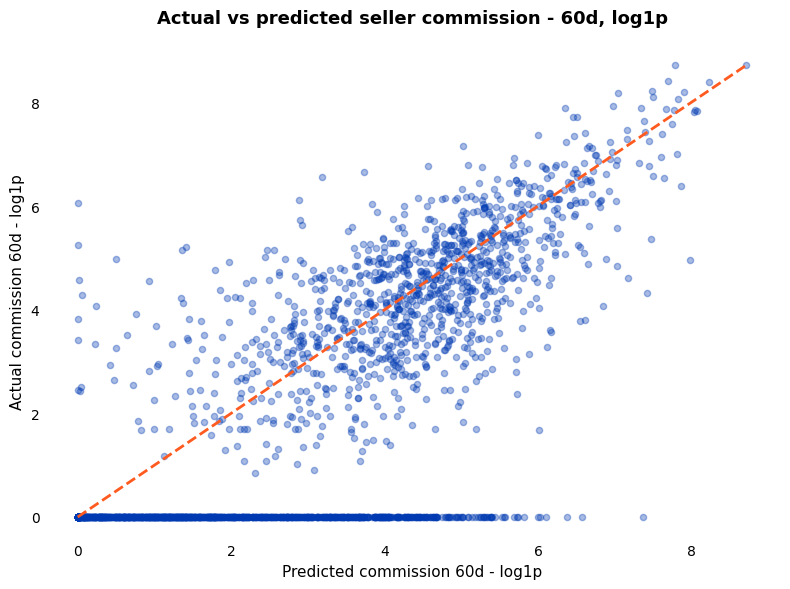

In [427]:
# ------------------------------------------------------------
# Plot 9: Actual vs predicted seller commission, log scale
# ------------------------------------------------------------

scatter_df = (
    score.reset_index()
    .rename(columns={"index": "seller_id"})[
        [
            "seller_id",
            f"expected_commission_{H_EVAL}d",
            f"actual_commission_{H_EVAL}d"
        ]
    ]
    .copy()
)

scatter_df["log_pred"] = np.log1p(
    scatter_df[f"expected_commission_{H_EVAL}d"]
)

scatter_df["log_actual"] = np.log1p(
    scatter_df[f"actual_commission_{H_EVAL}d"]
)

max_axis = max(
    scatter_df["log_pred"].max(),
    scatter_df["log_actual"].max()
)

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter points
ax.scatter(
    scatter_df["log_pred"],
    scatter_df["log_actual"],
    alpha=0.35,
    s=20,
    color="#003AB2"           # Blue Dark
)

# Perfect prediction line
ax.plot(
    [0, max_axis],
    [0, max_axis],
    linestyle="--",
    linewidth=2,
    color="#FF5A1F"           # Olist Orange
)

# Labels
ax.set_xlabel(
    f"Predicted commission {H_EVAL}d - log1p",
    fontsize=11
)

ax.set_ylabel(
    f"Actual commission {H_EVAL}d - log1p",
    fontsize=11
)

# Title
ax.set_title(
    f"Actual vs predicted seller commission - {H_EVAL}d, log1p",
    fontsize=13,
    fontweight="bold",
    pad=14
)

# Remove gridlines
ax.grid(False)

# Remove borders/spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Cleaner ticks
ax.tick_params(
    axis="both",
    length=0,
    labelsize=10
)

# Background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

plt.tight_layout()
# save_current_plot(f"09_actual_vs_predicted_commission_log_{H_EVAL}d.png")
plt.show()

**What does this plot show?**  
This is a scatter plot between log predicted commission and log actual commission at the seller level.

**Business interpretation**  
This plot evaluates the individual-level relationship between predictions and actual outcomes, while also helping identify outliers and sellers with actual commission equal to zero.

**Key findings and insights**  
There is a clear positive relationship: sellers with higher predicted commission generally also have higher actual commission. This further supports the conclusion that the model performs well for ranking purposes. However, many points are concentrated near the region where actual commission is close to zero, indicating that the model still assigns positive expected commission to sellers who ultimately generate no orders. This is a natural characteristic of probabilistic expectation models.

From a reliability perspective, this plot shows that the model is not suitable for guaranteeing highly accurate forecasts for individual sellers. Instead, it is more appropriate for segmentation and ranking based on probability and expected value. From a business perspective, the messaging should not be “Seller A will definitely generate X commission,” but rather “Seller A belongs to a high expected-value group and should therefore be prioritized.” For sellers with zero actual commission but positive predicted values, lower-cost activation campaigns or lightweight interventions are more appropriate than large immediate investments.